<a href="https://colab.research.google.com/github/Lingasamy-DS/Myfirst-Repo/blob/main/Global_Literacy_and_Education_Trend_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [287]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

** collecting the data of global lliterecy and stored as CSV file**

In [ ]:
import requests
import pandas as pd

df_adult= pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_adult
df_adult.to_csv("/content/drive/MyDrive/global literacy projects/final/literacy_rate.csv")

In [ ]:
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1725 entries, 0 to 1724
Data columns (total 4 columns):
 #   Column                                                                     Non-Null Count  Dtype  
---  ------                                                                     --------------  -----  
 0   entity                                                                     1725 non-null   object 
 1   code                                                                       996 non-null    object 
 2   year                                                                       1725 non-null   int64  
 3   adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99  1725 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 54.0+ KB


In [ ]:
df_adult.nunique()

,0
entity,195
code,177
year,51
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,940


In [ ]:
df_adult.describe()


,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
count,1725.000000,1725.000000
mean,2003.860870,77.336331
std,13.176796,19.335627
min,1970.000000,9.000000
25%,1994.000000,64.492390
50%,2007.000000,82.157580
75%,2015.000000,94.000000
max,2023.000000,100.000000


In [ ]:
df_adult.columns

Index(['entity', 'code', 'year',
       'adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99'],
      dtype='object')

In [ ]:
df_adult.isna().sum()

,0
entity,0
code,729
year,0
adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,0


In [ ]:
print(df_adult['entity'].value_counts())


entity
Middle East and North Africa (WB)        50
Latin America and the Caribbean (SDG)    50
Latin America and Caribbean (WB)         50
Lower-middle-income countries            49
Central and Southern Asia (SDG)          49
                                         ..
South Korea                               1
South Sudan                               1
Turkmenistan                              1
Ukraine                                   1
Yemen                                     1
Name: count, Length: 195, dtype: int64


** COLLECTING THE YOUTH LITERACY DATA**

In [ ]:
df_youth = pd.read_csv("https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_youth
df_youth.to_csv("/content/drive/MyDrive/global literacy projects/final/youth_literacy_rate.csv")

In [ ]:
df_youth.shape

(2002, 6)

In [ ]:
df_youth.columns

Index(['entity', 'code', 'year',
       'youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m',
       'youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f',
       'owid_region'],
      dtype='object')

In [ ]:
df_youth.nunique()

,0
entity,197
code,178
year,52
youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,1058
youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,1138
owid_region,6


In [ ]:
df_youth.entity.value_counts()

,count
entity,
Middle East and North Africa (WB),51
Latin America and Caribbean (WB),50
Latin America and the Caribbean (SDG),50
Lower-middle-income countries,49
Central and Southern Asia (SDG),49
...,...
Saint Vincent and the Grenadines,1
San Marino,1
Reunion,1


In [ ]:
df_adult['entity'] = df_adult['entity'].str.lower()
df_adult

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,afghanistan,AFG,1979,18.00000
1,afghanistan,AFG,2011,31.00000
2,afghanistan,AFG,2015,33.75384
3,afghanistan,AFG,2021,37.00000
4,albania,ALB,2001,99.00000
...,...,...,...,...
1720,zambia,ZMB,2010,83.00000
1721,zambia,ZMB,2018,71.13230
1722,zimbabwe,ZWE,1982,78.00000
1723,zimbabwe,ZWE,1992,84.00000


In [ ]:
df_youth['entity'] = df_youth['entity'].str.lower()
df_adult

,entity,code,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99
0,afghanistan,AFG,1979,18.00000
1,afghanistan,AFG,2011,31.00000
2,afghanistan,AFG,2015,33.75384
3,afghanistan,AFG,2021,37.00000
4,albania,ALB,2001,99.00000
...,...,...,...,...
1720,zambia,ZMB,2010,83.00000
1721,zambia,ZMB,2018,71.13230
1722,zimbabwe,ZWE,1982,78.00000
1723,zimbabwe,ZWE,1992,84.00000


In [ ]:
df_literacy = pd.merge(df_adult, df_youth, on=['entity', 'year'], how='outer')
df_literacy

,entity,code_x,year,adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99,code_y,youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m,youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f,owid_region
0,afghanistan,AFG,1979,18.00000,AFG,46.00000,11.00000,Asia
1,afghanistan,AFG,2011,31.00000,AFG,62.00000,32.00000,Asia
2,afghanistan,AFG,2015,33.75384,AFG,57.73505,25.48416,Asia
3,afghanistan,AFG,2021,37.00000,AFG,71.00000,42.00000,Asia
4,afghanistan,NaN,2022,NaN,AFG,83.40000,44.17171,Asia
...,...,...,...,...,...,...,...,...
2014,zimbabwe,ZWE,1982,78.00000,ZWE,94.00000,85.00000,Africa
2015,zimbabwe,ZWE,1992,84.00000,ZWE,97.00000,94.00000,Africa
2016,zimbabwe,NaN,2009,NaN,ZWE,NaN,95.65000,Africa
2017,zimbabwe,NaN,2014,NaN,ZWE,NaN,96.31000,Africa


In [ ]:
df_literacy = df_literacy.rename(columns={"entity":"country","adult_literacy_rate__population_15plus_years__both_sexes__pct__lr_ag15t99":"adult_literacy_rate","youth_literacy_rate__population_15_24_years__male__pct__lr_ag15t24_m":"youth_literacy_male","youth_literacy_rate__population_15_24_years__female__pct__lr_ag15t24_f":"youth_literacy_female","owid_region":"region"})
df_literacy

,country,code_x,year,adult_literacy_rate,code_y,youth_literacy_male,youth_literacy_female,region
0,afghanistan,AFG,1979,18.00000,AFG,46.00000,11.00000,Asia
1,afghanistan,AFG,2011,31.00000,AFG,62.00000,32.00000,Asia
2,afghanistan,AFG,2015,33.75384,AFG,57.73505,25.48416,Asia
3,afghanistan,AFG,2021,37.00000,AFG,71.00000,42.00000,Asia
4,afghanistan,NaN,2022,NaN,AFG,83.40000,44.17171,Asia
...,...,...,...,...,...,...,...,...
2014,zimbabwe,ZWE,1982,78.00000,ZWE,94.00000,85.00000,Africa
2015,zimbabwe,ZWE,1992,84.00000,ZWE,97.00000,94.00000,Africa
2016,zimbabwe,NaN,2009,NaN,ZWE,NaN,95.65000,Africa
2017,zimbabwe,NaN,2014,NaN,ZWE,NaN,96.31000,Africa


In [ ]:
df_literacy = df_literacy.drop(columns =["code_x", "code_y"])

In [ ]:
df_literacy

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region
0,afghanistan,1979,18.00000,46.00000,11.00000,Asia
1,afghanistan,2011,31.00000,62.00000,32.00000,Asia
2,afghanistan,2015,33.75384,57.73505,25.48416,Asia
3,afghanistan,2021,37.00000,71.00000,42.00000,Asia
4,afghanistan,2022,NaN,83.40000,44.17171,Asia
...,...,...,...,...,...,...
2014,zimbabwe,1982,78.00000,94.00000,85.00000,Africa
2015,zimbabwe,1992,84.00000,97.00000,94.00000,Africa
2016,zimbabwe,2009,NaN,NaN,95.65000,Africa
2017,zimbabwe,2014,NaN,NaN,96.31000,Africa


In [ ]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                2019 non-null   object 
 1   year                   2019 non-null   int64  
 2   adult_literacy_rate    1725 non-null   float64
 3   youth_literacy_male    1925 non-null   float64
 4   youth_literacy_female  2002 non-null   float64
 5   region                 1211 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 94.8+ KB


**Filling the NAN Values**

In [ ]:
df_literacy.shape

(2019, 6)

In [ ]:
df_literacy["region"][df_literacy["region"].isna()]

,region
22,NaN
209,NaN
210,NaN
211,NaN
212,NaN
...,...
2000,NaN
2001,NaN
2002,NaN
2003,NaN


In [ ]:
df_literacy.info()
df_literacy

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3727 entries, 0 to 3726
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                3727 non-null   object 
 1   year                   3727 non-null   int64  
 2   adult_literacy_rate    1725 non-null   float64
 3   youth_literacy_male    1925 non-null   float64
 4   youth_literacy_female  2002 non-null   float64
 5   region                 1211 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 174.8+ KB


,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region
0,Afghanistan,1979,18.00000,NaN,NaN,NaN
1,Afghanistan,2011,31.00000,NaN,NaN,NaN
2,Afghanistan,2015,33.75384,NaN,NaN,NaN
3,Afghanistan,2021,37.00000,NaN,NaN,NaN
4,Albania,2001,99.00000,NaN,NaN,NaN
...,...,...,...,...,...,...
3722,zimbabwe,1982,NaN,94.00000,85.0000,Africa
3723,zimbabwe,1992,NaN,97.00000,94.0000,Africa
3724,zimbabwe,2009,NaN,NaN,95.6500,Africa
3725,zimbabwe,2014,NaN,NaN,96.3100,Africa


In [ ]:
mean_adult_literacy_per_country = df_literacy.groupby('country')['adult_literacy_rate'].mean().reset_index()
df_literacy["adult_literacy_rate"] = df_literacy["adult_literacy_rate"].fillna(mean_adult_literacy_per_country["adult_literacy_rate"])

In [ ]:
df_literacy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019 entries, 0 to 2018
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                2019 non-null   object 
 1   year                   2019 non-null   int64  
 2   adult_literacy_rate    2010 non-null   float64
 3   youth_literacy_male    2014 non-null   float64
 4   youth_literacy_female  2015 non-null   float64
 5   region                 1211 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 94.8+ KB


In [ ]:
df_literacy['adult_literacy_rate'] = df_literacy.groupby('country')['adult_literacy_rate'].transform(lambda x: x.fillna(x.mean()))
df_literacy['youth_literacy_male'] = df_literacy.groupby('country')['youth_literacy_male'].transform(lambda x: x.fillna(x.mean()))
df_literacy['youth_literacy_female'] = df_literacy.groupby('country')['youth_literacy_female'].transform(lambda x: x.fillna(x.mean()))
display(df_literacy.head())

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region
0,afghanistan,1979,18.000000,46.00000,11.00000,Asia
1,afghanistan,2011,31.000000,62.00000,32.00000,Asia
2,afghanistan,2015,33.753840,57.73505,25.48416,Asia
3,afghanistan,2021,37.000000,71.00000,42.00000,Asia
4,afghanistan,2022,66.411953,83.40000,44.17171,Asia


In [ ]:
df_literacy_filtered = df_literacy[(df_literacy['year'] >= 1990) & (df_literacy['year'] <= 2025)].reset_index(drop=True)
df_literacy_filtered

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region
0,afghanistan,2011,31.000000,62.00000,32.00000,Asia
1,afghanistan,2015,33.753840,57.73505,25.48416,Asia
2,afghanistan,2021,37.000000,71.00000,42.00000,Asia
3,afghanistan,2022,66.411953,83.40000,44.17171,Asia
4,albania,2001,99.000000,99.00000,99.00000,Europe
...,...,...,...,...,...,...
1707,zambia,2018,71.132300,82.44786,72.90992,Africa
1708,zimbabwe,1992,84.000000,97.00000,94.00000,Africa
1709,zimbabwe,2009,85.075850,93.92461,95.65000,Africa
1710,zimbabwe,2014,85.075850,93.92461,96.31000,Africa


In [ ]:
Frequent_region = df_literacy_filtered['region'].mode()[0]
df_literacy_filtered['region'] = df_literacy_filtered['region'].fillna(Frequent_region)

In [ ]:
df_literacy_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1712 entries, 0 to 1711
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   country                1712 non-null   object 
 1   year                   1712 non-null   int64  
 2   adult_literacy_rate    1703 non-null   float64
 3   youth_literacy_male    1708 non-null   float64
 4   youth_literacy_female  1709 non-null   float64
 5   region                 1712 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 80.4+ KB


In [ ]:
df_literacy_filtered.dropna()

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region
0,afghanistan,2011,31.000000,62.00000,32.00000,Asia
1,afghanistan,2015,33.753840,57.73505,25.48416,Asia
2,afghanistan,2021,37.000000,71.00000,42.00000,Asia
3,afghanistan,2022,66.411953,83.40000,44.17171,Asia
4,albania,2001,99.000000,99.00000,99.00000,Europe
...,...,...,...,...,...,...
1707,zambia,2018,71.132300,82.44786,72.90992,Africa
1708,zimbabwe,1992,84.000000,97.00000,94.00000,Africa
1709,zimbabwe,2009,85.075850,93.92461,95.65000,Africa
1710,zimbabwe,2014,85.075850,93.92461,96.31000,Africa


In [ ]:
df_literacy_cleaned = df_literacy_filtered
df_literacy_cleaned.to_csv("/content/drive/MyDrive/global literacy projects/final/df_literacy_cleaned.csv")

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drive/MyDrive/global literacy projects/final/df_literacy_cleaned.csv")
df

,Unnamed: 0,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region
0,0,afghanistan,2011,31.000000,62.00000,32.00000,Asia
1,1,afghanistan,2015,33.753840,57.73505,25.48416,Asia
2,2,afghanistan,2021,37.000000,71.00000,42.00000,Asia
3,3,afghanistan,2022,66.411953,83.40000,44.17171,Asia
4,4,albania,2001,99.000000,99.00000,99.00000,Europe
...,...,...,...,...,...,...,...
1695,1707,zambia,2018,71.132300,82.44786,72.90992,Africa
1696,1708,zimbabwe,1992,84.000000,97.00000,94.00000,Africa
1697,1709,zimbabwe,2009,85.075850,93.92461,95.65000,Africa
1698,1710,zimbabwe,2014,85.075850,93.92461,96.31000,Africa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1700 non-null   int64  
 1   country                1700 non-null   object 
 2   year                   1700 non-null   int64  
 3   adult_literacy_rate    1700 non-null   float64
 4   youth_literacy_male    1700 non-null   float64
 5   youth_literacy_female  1700 non-null   float64
 6   region                 1700 non-null   object 
dtypes: float64(3), int64(2), object(2)
memory usage: 93.1+ KB


**LITERACY GAP ANALYZE BETWEEN THE MALE AND FEMALE**

In [ ]:
df['literacy_gender_gap'] = abs(df['youth_literacy_male'] - df['youth_literacy_female'])
display(df)

,Unnamed: 0,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap
0,0,afghanistan,2011,31.000000,62.00000,32.00000,Asia,30.00000
1,1,afghanistan,2015,33.753840,57.73505,25.48416,Asia,32.25089
2,2,afghanistan,2021,37.000000,71.00000,42.00000,Asia,29.00000
3,3,afghanistan,2022,66.411953,83.40000,44.17171,Asia,39.22829
4,4,albania,2001,99.000000,99.00000,99.00000,Europe,0.00000
...,...,...,...,...,...,...,...,...
1695,1707,zambia,2018,71.132300,82.44786,72.90992,Africa,9.53794
1696,1708,zimbabwe,1992,84.000000,97.00000,94.00000,Africa,3.00000
1697,1709,zimbabwe,2009,85.075850,93.92461,95.65000,Africa,1.72539
1698,1710,zimbabwe,2014,85.075850,93.92461,96.31000,Africa,2.38539


** AVERAGHE LITERACY RATES OF THE YOUTHS**

In [ ]:
df['youth_literacy_average'] = (df['youth_literacy_male'] + df['youth_literacy_female']) / 2
display(df.head())

,Unnamed: 0,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average
0,0,afghanistan,2011,31.000000,62.00000,32.00000,Asia,30.00000,47.000000
1,1,afghanistan,2015,33.753840,57.73505,25.48416,Asia,32.25089,41.609605
2,2,afghanistan,2021,37.000000,71.00000,42.00000,Asia,29.00000,56.500000
3,3,afghanistan,2022,66.411953,83.40000,44.17171,Asia,39.22829,63.785855
4,4,albania,2001,99.000000,99.00000,99.00000,Europe,0.00000,99.000000


** YEAR TO YEAR LITERACY RATE DIFFENECE ON PERCENTAGE**

In [ ]:
df['youth_literacy_PCT']= df.groupby("country")['youth_literacy_average'].pct_change(fill_method=None)*100

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1700 non-null   int64  
 1   country                 1700 non-null   object 
 2   year                    1700 non-null   int64  
 3   adult_literacy_rate     1700 non-null   float64
 4   youth_literacy_male     1700 non-null   float64
 5   youth_literacy_female   1700 non-null   float64
 6   region                  1700 non-null   object 
 7   literacy_gender_gap     1700 non-null   float64
 8   youth_literacy_average  1700 non-null   float64
 9   youth_literacy_PCT      1521 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 132.9+ KB


**FILLING THE NAN VALUE OF THE YOUTH LITERACY PERCENTAGE  ON THE FIRST ROW OF THE EVERY COUNTRY AS """ZERO""" FOR THE YEAR OF 1990**

In [ ]:
df["youth_literacy_PCT"]= df["youth_literacy_PCT"].fillna(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1700 non-null   int64  
 1   country                 1700 non-null   object 
 2   year                    1700 non-null   int64  
 3   adult_literacy_rate     1700 non-null   float64
 4   youth_literacy_male     1700 non-null   float64
 5   youth_literacy_female   1700 non-null   float64
 6   region                  1700 non-null   object 
 7   literacy_gender_gap     1700 non-null   float64
 8   youth_literacy_average  1700 non-null   float64
 9   youth_literacy_PCT      1700 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 132.9+ KB


In [ ]:
df.to_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              1700 non-null   int64  
 1   country                 1700 non-null   object 
 2   year                    1700 non-null   int64  
 3   adult_literacy_rate     1700 non-null   float64
 4   youth_literacy_male     1700 non-null   float64
 5   youth_literacy_female   1700 non-null   float64
 6   region                  1700 non-null   object 
 7   literacy_gender_gap     1700 non-null   float64
 8   youth_literacy_average  1700 non-null   float64
 9   youth_literacy_PCT      1700 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 132.9+ KB


In [ ]:
df["youth_literacy_female"].value_counts()

,count
youth_literacy_female,
100.00000,151
99.00000,151
98.00000,44
96.00000,28
97.00000,28
...,...
84.83368,1
85.37423,1
85.40587,1


In [ ]:
df.size

17000

In [ ]:
df.shape

(1700, 10)

**ILLITERATE POPULATION**

**COLLECTING THE FILES AND STORING AS A PANDAS DATA FRAME**

In [ ]:
df_illiterate_pop= pd.read_csv("https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_illiterate_pop
df_illiterate_pop.to_csv("/content/drive/MyDrive/global literacy projects/final/illiterate_pop.csv")

In [ ]:
df_illiterate_pop

,entity,code,year,illiteracy_rate,literacy_rate
0,Afghanistan,AFG,1950,97.000000,3.00000
1,Afghanistan,AFG,1979,82.000000,18.00000
2,Afghanistan,AFG,2011,69.000000,31.00000
3,Afghanistan,AFG,2015,66.246155,33.75384
4,Afghanistan,AFG,2021,63.000000,37.00000
...,...,...,...,...,...
2054,Zanzibar,OWID_ZAN,1950,92.500000,7.50000
2055,Zimbabwe,ZWE,1950,77.500000,22.50000
2056,Zimbabwe,ZWE,1982,22.000000,78.00000
2057,Zimbabwe,ZWE,1992,16.000000,84.00000


In [ ]:
df_illiterate_pop = df_illiterate_pop.rename(columns ={"entity":"country"})
df_illiterate_pop = df_illiterate_pop.drop(columns =["code"])

In [ ]:
df_illiterate_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2059 non-null   object 
 1   year             2059 non-null   int64  
 2   illiteracy_rate  2059 non-null   float64
 3   literacy_rate    2059 non-null   float64
dtypes: float64(2), int64(1), object(1)
memory usage: 64.5+ KB


In [ ]:
df_illiterate_pop = df_illiterate_pop[(df_illiterate_pop["year"]>=1990) & (df_illiterate_pop["year"]<=2025)].reset_index(drop=True)
df_illiterate_pop

,country,year,illiteracy_rate,literacy_rate
0,Afghanistan,2011,69.000000,31.00000
1,Afghanistan,2015,66.246155,33.75384
2,Afghanistan,2021,63.000000,37.00000
3,Albania,2001,1.000000,99.00000
4,Albania,2008,4.000000,96.00000
...,...,...,...,...
1414,Zambia,2002,31.000000,69.00000
1415,Zambia,2010,17.000000,83.00000
1416,Zambia,2018,28.867699,71.13230
1417,Zimbabwe,1992,16.000000,84.00000


In [ ]:
df_illiterate_pop.to_csv("/content/drive/MyDrive/global literacy projects/final/illiterate_cleaned.csv")

NameError: name 'df_illiterate_pop' is not defined

In [ ]:
#df_illiteracy = pd.read_csv("/content/drive/MyDrive/global literacy projects/illiterate_pop.csv")
#df_illiteracy = df_illiteracy.drop(columns = ["Unnamed: 0"])
#df_illiteracy = df_illiteracy.rename(columns = {"entity":"country"})
#df_illiteracy = df_illiteracy.drop(columns = ["code"])
#df_illiteracy = df_illiteracy[(df_illiteracy["year"]>=1990) & (df_illiteracy["year"]<=2026)].reset_index(drop=True)
#df_illiteracy["literacy_gap"] = abs((df_illiteracy["illiteracy_rate"])-(df_illiteracy["literacy_rate"]))
#df_illiteracy

,country,year,illiteracy_rate,literacy_rate,literacy_gap
0,Afghanistan,2011,69.000000,31.00000,38.000000
1,Afghanistan,2015,66.246155,33.75384,32.492315
2,Afghanistan,2021,63.000000,37.00000,26.000000
3,Albania,2001,1.000000,99.00000,98.000000
4,Albania,2008,4.000000,96.00000,92.000000
...,...,...,...,...,...
1414,Zambia,2002,31.000000,69.00000,38.000000
1415,Zambia,2010,17.000000,83.00000,66.000000
1416,Zambia,2018,28.867699,71.13230,42.264601
1417,Zimbabwe,1992,16.000000,84.00000,68.000000


In [ ]:
df_illiterate_pop["literacy_gap"] = abs((df_illiterate_pop["illiteracy_rate"])-(df_illiterate_pop["literacy_rate"]))

In [ ]:
df_illiterate_pop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          2059 non-null   object 
 1   year             2059 non-null   int64  
 2   illiteracy_rate  2059 non-null   float64
 3   literacy_rate    2059 non-null   float64
 4   literacy_gap     2059 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 80.6+ KB


In [ ]:
df_illiterate_pop.columns

Index(['country', 'year', 'illiteracy_rate', 'literacy_rate', 'literacy_gap'], dtype='object')

In [ ]:
df_illiterate_pop["country"].value_counts()

,count
country,
World,59
Latin America and Caribbean (WB),50
Latin America and the Caribbean (SDG),50
Middle East and North Africa (WB),50
Lower-middle-income countries,49
...,...
Tokelau,1
Switzerland,1
USSR,1


In [ ]:
df_illiterate_pop.to_csv("/content/drive/MyDrive/A Global Literacy/illiterate_rate")


** Schooling data collection**

In [ ]:
df_Avg_School_year=pd.read_csv("https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_Avg_School_year
df_Avg_School_year.to_csv("/content/drive/MyDrive/global literacy projects/Avg_School_year.csv")

In [ ]:
df_school = pd.read_csv("/content/drive/MyDrive/global literacy projects/Avg_School_year.csv")
df_school = df_school.drop(columns = ["Unnamed: 0"])
df_school.head()

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1870,NaN,0.01,4101170.0,Asia
1,Afghanistan,AFG,1875,NaN,0.01,4193635.0,Asia
2,Afghanistan,AFG,1880,NaN,0.01,4288021.0,Asia
3,Afghanistan,AFG,1885,NaN,0.01,4384343.0,Asia
4,Afghanistan,AFG,1890,NaN,0.01,4482635.0,Asia


In [ ]:
df_school.columns

Index(['entity', 'code', 'year', 'literacy_rate',
       'mf_youth_and_adults__15_64_years__average_years_of_education',
       'population_historical', 'owid_region'],
      dtype='object')

In [ ]:
df_school = df_school.rename(columns={
    "entity": "country",
    "mf_youth_and_adults__15_64_years__average_years_of_education": "Average_years_of_education",
    "population_historical": "Population_historical",
    "owid_region": "region"
})
display(df_school.head(20))


,country,code,year,literacy_rate,Average_years_of_education,Population_historical,region
0,Afghanistan,AFG,1990,NaN,2.060000,1.204566e+07,Asia
1,Afghanistan,AFG,1995,NaN,2.400000,1.706584e+07,Asia
2,Afghanistan,AFG,2000,NaN,3.030000,2.013033e+07,Asia
3,Afghanistan,AFG,2005,NaN,3.320000,2.440458e+07,Asia
4,Afghanistan,AFG,2010,NaN,3.930000,2.828409e+07,Asia
5,Afghanistan,AFG,2011,31.00000,NaN,2.934771e+07,Asia
6,Afghanistan,AFG,2015,33.75384,4.810000,3.383177e+07,Asia
7,Afghanistan,AFG,2020,NaN,5.690000,3.906898e+07,Asia
8,Afghanistan,AFG,2021,37.00000,NaN,4.000041e+07,Asia
9,Africa,NaN,1990,NaN,4.142478,6.437753e+08,NaN


In [ ]:
df_school.columns

Index(['country', 'code', 'year', 'literacy_rate',
       'Average_years_of_education', 'Population_historical', 'region'],
      dtype='object')

In [ ]:
df_school = df_school[(df_school["year"] >= 1990) & (df_school["year"]<= 2025)].reset_index(drop=True)
#df_school_africa = df_school[df_school["country"] == "africa"]
df_school

,entity,code,year,literacy_rate,mf_youth_and_adults__15_64_years__average_years_of_education,population_historical,owid_region
0,Afghanistan,AFG,1990,NaN,2.06,12045664.0,Asia
1,Afghanistan,AFG,1995,NaN,2.40,17065837.0,Asia
2,Afghanistan,AFG,2000,NaN,3.03,20130334.0,Asia
3,Afghanistan,AFG,2005,NaN,3.32,24404575.0,Asia
4,Afghanistan,AFG,2010,NaN,3.93,28284088.0,Asia
...,...,...,...,...,...,...,...
2131,Zimbabwe,ZWE,2005,NaN,7.65,12483433.0,Africa
2132,Zimbabwe,ZWE,2010,NaN,7.86,13356551.0,Africa
2133,Zimbabwe,ZWE,2015,NaN,8.03,14399008.0,Africa
2134,Zimbabwe,ZWE,2019,93.22755,NaN,15271377.0,Africa


**Country name changing**

In [ ]:
df_school['country'] = df_school['country'].str.lower()
df_school

,country,code,year,literacy_rate,Average_years_of_education,Population_historical,region
0,afghanistan,AFG,1990,NaN,2.06,12045664.0,Asia
1,afghanistan,AFG,1995,NaN,2.40,17065837.0,Asia
2,afghanistan,AFG,2000,NaN,3.03,20130334.0,Asia
3,afghanistan,AFG,2005,NaN,3.32,24404575.0,Asia
4,afghanistan,AFG,2010,NaN,3.93,28284088.0,Asia
...,...,...,...,...,...,...,...
2131,zimbabwe,ZWE,2005,NaN,7.65,12483433.0,Africa
2132,zimbabwe,ZWE,2010,NaN,7.86,13356551.0,Africa
2133,zimbabwe,ZWE,2015,NaN,8.03,14399008.0,Africa
2134,zimbabwe,ZWE,2019,93.22755,NaN,15271377.0,Africa


In [ ]:
df_school.isna().sum().sum()

np.int64(3631)

In [ ]:
df_school.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     2136 non-null   object 
 1   code                        1547 non-null   object 
 2   year                        2136 non-null   int64  
 3   literacy_rate               1385 non-null   float64
 4   Average_years_of_education  884 non-null    float64
 5   Population_historical       1686 non-null   float64
 6   region                      1547 non-null   object 
dtypes: float64(3), int64(1), object(3)
memory usage: 116.9+ KB


In [ ]:
df_school = df_school.drop(columns ={"code"})

**FILLING THE NAN VALUE IN REGION COLUMN**

In [ ]:
Frequent_region = df_school['region'].mode()[0]
Frequent_region
df_school['region'] = df_school['region'].fillna(Frequent_region)

In [ ]:
df_school['literacy_rate'] = df_school.groupby('country')['literacy_rate'].transform(lambda x: x.fillna(x.mean()))
df_school['literacy_rate'] = df_school['literacy_rate'].fillna(df_school['literacy_rate'].mean())
print('Missing values after imputing literacy_rate:', df_school['literacy_rate'].isna().sum())

Missing values after imputing literacy_rate: 0


In [ ]:
df_school['Average_years_of_education'] = df_school.groupby('country')['Average_years_of_education'].transform(lambda x: x.fillna(x.mean()))
df_school['Average_years_of_education'] = df_school['Average_years_of_education'].fillna(df_school['Average_years_of_education'].mean())
print('Missing values after imputing Average_years_of_education:', df_school['Average_years_of_education'].isna().sum())

Missing values after imputing Average_years_of_education: 0


In [ ]:
df_school['Population_historical'] = df_school.groupby('country')['Population_historical'].transform(lambda x: x.fillna(x.mean()))
df_school['Population_historical'] = df_school['Population_historical'].fillna(df_school['Population_historical'].mean())
print('Missing values after imputing Population_historical:', df_school['Population_historical'].isna().sum())

Missing values after imputing Population_historical: 0


In [ ]:
df_school.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2136 entries, 0 to 2135
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     2136 non-null   object 
 1   year                        2136 non-null   int64  
 2   literacy_rate               2136 non-null   float64
 3   Average_years_of_education  2136 non-null   float64
 4   Population_historical       2136 non-null   float64
 5   region                      2136 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 100.3+ KB


In [ ]:
df_school.head(10)

,country,year,literacy_rate,Average_years_of_education,Population_historical,region
0,afghanistan,1990,33.917947,2.060000,12045664.0,Asia
1,afghanistan,1995,33.917947,2.400000,17065837.0,Asia
2,afghanistan,2000,33.917947,3.030000,20130334.0,Asia
3,afghanistan,2005,33.917947,3.320000,24404575.0,Asia
4,afghanistan,2010,33.917947,3.930000,28284088.0,Asia
5,afghanistan,2011,31.000000,3.605714,29347708.0,Asia
6,afghanistan,2015,33.753840,4.810000,33831767.0,Asia
7,afghanistan,2020,33.917947,5.690000,39068977.0,Asia
8,afghanistan,2021,37.000000,3.605714,40000410.0,Asia
9,africa,1990,79.856564,4.142478,643775322.0,Asia


In [ ]:
df_school.to_csv("/content/drive/MyDrive/A Global Literacy/AVG_school_cleaned.csv")

In [ ]:
df_s= pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiterate_rate")
df_s

,Unnamed: 0,country,year,illiteracy_rate,literacy_rate,literacy_gap
0,0,Afghanistan,1950,97.000000,3.00000,94.000000
1,1,Afghanistan,1979,82.000000,18.00000,64.000000
2,2,Afghanistan,2011,69.000000,31.00000,38.000000
3,3,Afghanistan,2015,66.246155,33.75384,32.492315
4,4,Afghanistan,2021,63.000000,37.00000,26.000000
...,...,...,...,...,...,...
2054,2054,Zanzibar,1950,92.500000,7.50000,85.000000
2055,2055,Zimbabwe,1950,77.500000,22.50000,55.000000
2056,2056,Zimbabwe,1982,22.000000,78.00000,56.000000
2057,2057,Zimbabwe,1992,16.000000,84.00000,68.000000


In [ ]:
df_s.to_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")

In [ ]:
df_s1 = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned")

In [ ]:
df_s1.info()
df_s1 = df_s1.drop(columns = ["Unnamed: 0","Unnamed: 0.1"])
df_s1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0.1            1700 non-null   int64  
 1   Unnamed: 0              1700 non-null   int64  
 2   country                 1700 non-null   object 
 3   year                    1700 non-null   int64  
 4   adult_literacy_rate     1700 non-null   float64
 5   youth_literacy_male     1700 non-null   float64
 6   youth_literacy_female   1700 non-null   float64
 7   region                  1700 non-null   object 
 8   literacy_gender_gap     1700 non-null   float64
 9   youth_literacy_average  1700 non-null   float64
 10  youth_literacy_PCT      1700 non-null   float64
dtypes: float64(6), int64(3), object(2)
memory usage: 146.2+ KB


,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT
0,afghanistan,2011,31.000000,62.00000,32.00000,Asia,30.00000,47.000000,0.000000
1,afghanistan,2015,33.753840,57.73505,25.48416,Asia,32.25089,41.609605,-11.468926
2,afghanistan,2021,37.000000,71.00000,42.00000,Asia,29.00000,56.500000,35.785956
3,afghanistan,2022,66.411953,83.40000,44.17171,Asia,39.22829,63.785855,12.895319
4,albania,2001,99.000000,99.00000,99.00000,Europe,0.00000,99.000000,0.000000


In [ ]:
df_s1.to_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv",index = False)

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
df

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT
0,afghanistan,2011,31.000000,62.00000,32.00000,Asia,30.00000,47.000000,0.000000
1,afghanistan,2015,33.753840,57.73505,25.48416,Asia,32.25089,41.609605,-11.468926
2,afghanistan,2021,37.000000,71.00000,42.00000,Asia,29.00000,56.500000,35.785956
3,afghanistan,2022,66.411953,83.40000,44.17171,Asia,39.22829,63.785855,12.895319
4,albania,2001,99.000000,99.00000,99.00000,Europe,0.00000,99.000000,0.000000
...,...,...,...,...,...,...,...,...,...
1695,zambia,2018,71.132300,82.44786,72.90992,Africa,9.53794,77.678890,-12.720348
1696,zimbabwe,1992,84.000000,97.00000,94.00000,Africa,3.00000,95.500000,0.000000
1697,zimbabwe,2009,85.075850,93.92461,95.65000,Africa,1.72539,94.787305,-0.746277
1698,zimbabwe,2014,85.075850,93.92461,96.31000,Africa,2.38539,95.117305,0.348148


In [ ]:
df_s.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2059 non-null   int64  
 1   country          2059 non-null   object 
 2   year             2059 non-null   int64  
 3   illiteracy_rate  2059 non-null   float64
 4   literacy_rate    2059 non-null   float64
 5   literacy_gap     2059 non-null   float64
dtypes: float64(3), int64(2), object(1)
memory usage: 96.6+ KB


**GDP PERCAPTA DATA COLLECTION**

In [ ]:
df_GDP=pd.read_csv("https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
df_GDP
df_GDP.to_csv("/content/drive/MyDrive/global literacy projects/GDP.csv")

In [ ]:
df_GDP.shape

(7240, 5)

In [ ]:
df_GDP.columns

Index(['entity', 'code', 'year', 'ny_gdp_pcap_pp_kd', 'owid_region'], dtype='object')

In [ ]:
df_GDP.rename(columns = {"entity":"country","code":"code", "year":"year","ny_gdp_pcap_pp_kd":"GDP_PCAP", "owid_region":"region"}, inplace=True)

In [ ]:
df_GDP.columns

Index(['country', 'code', 'year', 'GDP_PCAP', 'region'], dtype='object')

In [ ]:
df_GDP = df_GDP[(df_GDP["year"]>=1990) & (df_GDP["year"]<=2025)]
df_GDP

,country,code,year,GDP_PCAP,region
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia
...,...,...,...,...,...
7235,Zimbabwe,ZWE,2020,4527.7197,Africa
7236,Zimbabwe,ZWE,2021,4827.0890,Africa
7237,Zimbabwe,ZWE,2022,5036.7610,Africa
7238,Zimbabwe,ZWE,2023,5218.0225,Africa


In [ ]:
df_GDP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7240 entries, 0 to 7239
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   country   7240 non-null   object 
 1   code      7240 non-null   object 
 2   year      7240 non-null   int64  
 3   GDP_PCAP  7240 non-null   float64
 4   region    6785 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 282.9+ KB


In [ ]:
df_GDP['country'] = df_GDP['country'].str.lower()
df_GDP["region"] = df_GDP["region"].str.lower()

df_GDP

,country,code,year,GDP_PCAP,region
0,afghanistan,AFG,2000,1617.8264,asia
1,afghanistan,AFG,2001,1454.1108,asia
2,afghanistan,AFG,2002,1774.3087,asia
3,afghanistan,AFG,2003,1815.9282,asia
4,afghanistan,AFG,2004,1776.9182,asia
...,...,...,...,...,...
7235,zimbabwe,ZWE,2020,4527.7197,africa
7236,zimbabwe,ZWE,2021,4827.0890,africa
7237,zimbabwe,ZWE,2022,5036.7610,africa
7238,zimbabwe,ZWE,2023,5218.0225,africa


In [ ]:
df_school["region"] = df_school["region"].str.lower()
df_school

,country,year,literacy_rate,Average_years_of_education,Population_historical,region
0,afghanistan,1990,33.917947,2.06,12045664.0,asia
1,afghanistan,1995,33.917947,2.40,17065837.0,asia
2,afghanistan,2000,33.917947,3.03,20130334.0,asia
3,afghanistan,2005,33.917947,3.32,24404575.0,asia
4,afghanistan,2010,33.917947,3.93,28284088.0,asia
...,...,...,...,...,...,...
2131,zimbabwe,2005,88.613775,7.65,12483433.0,africa
2132,zimbabwe,2010,88.613775,7.86,13356551.0,africa
2133,zimbabwe,2015,88.613775,8.03,14399008.0,africa
2134,zimbabwe,2019,93.227550,7.42,15271377.0,africa


In [ ]:
df_GDP = df_GDP.drop(columns = ["code"])

In [ ]:
mode = df_GDP["region"].mode()[0]
df_GDP["region"]= df_GDP["region"].fillna(mode)

In [ ]:
df_GDP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7240 entries, 0 to 7239
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   country   7240 non-null   object 
 1   year      7240 non-null   int64  
 2   GDP_PCAP  7240 non-null   float64
 3   region    7240 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 226.4+ KB


In [ ]:
df_GDP.to_csv("/content/drive/MyDrive/A Global Literacy/GDP_cleaned.csv", index=False)

In [ ]:
df_gdp_schooling_inner = pd.merge(df_school, df_GDP, on=['country', 'year', 'region'], how='inner')
df_gdp_schooling_inner

,country,year,literacy_rate,Average_years_of_education,Population_historical,region,GDP_PCAP
0,afghanistan,2000,33.917947,3.030000,20130334.0,asia,1617.8264
1,afghanistan,2005,33.917947,3.320000,24404575.0,asia,1908.1147
2,afghanistan,2010,33.917947,3.930000,28284088.0,asia,2848.5862
3,afghanistan,2011,31.000000,3.605714,29347708.0,asia,2757.0525
4,afghanistan,2015,33.753840,4.810000,33831767.0,asia,2967.6921
...,...,...,...,...,...,...,...
1487,zimbabwe,2005,88.613775,7.650000,12483433.0,africa,4004.6646
1488,zimbabwe,2010,88.613775,7.860000,13356551.0,africa,3885.3938
1489,zimbabwe,2015,88.613775,8.030000,14399008.0,africa,5102.7144
1490,zimbabwe,2019,93.227550,7.420000,15271377.0,africa,4993.8438


In [ ]:
df_gdp_schooling_inner.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1492 entries, 0 to 1491
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country                     1492 non-null   object 
 1   year                        1492 non-null   int64  
 2   literacy_rate               1492 non-null   float64
 3   Average_years_of_education  1492 non-null   float64
 4   Population_historical       1492 non-null   float64
 5   region                      1492 non-null   object 
 6   GDP_PCAP                    1492 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 81.7+ KB


In [ ]:
df_gdp_schooling_inner.columns

Index(['country', 'year', 'literacy_rate', 'Average_years_of_education',
       'Population_historical', 'region', 'GDP_PCAP', 'Total_GDP',
       'GDP_per_year_of_Education'],
      dtype='object')

In [ ]:
df_gdp_schooling_inner["Total_GDP"] = df_gdp_schooling_inner["GDP_PCAP"]*df_gdp_schooling_inner["Population_historical"]
df_gdp_schooling_inner

,country,year,literacy_rate,Average_years_of_education,Population_historical,region,GDP_PCAP,Total_GDP
0,afghanistan,2000,33.917947,3.030000,20130334.0,asia,1617.8264,3.256739e+10
1,afghanistan,2005,33.917947,3.320000,24404575.0,asia,1908.1147,4.656673e+10
2,afghanistan,2010,33.917947,3.930000,28284088.0,asia,2848.5862,8.056966e+10
3,afghanistan,2011,31.000000,3.605714,29347708.0,asia,2757.0525,8.091317e+10
4,afghanistan,2015,33.753840,4.810000,33831767.0,asia,2967.6921,1.004023e+11
...,...,...,...,...,...,...,...,...
1487,zimbabwe,2005,88.613775,7.650000,12483433.0,africa,4004.6646,4.999196e+10
1488,zimbabwe,2010,88.613775,7.860000,13356551.0,africa,3885.3938,5.189546e+10
1489,zimbabwe,2015,88.613775,8.030000,14399008.0,africa,5102.7144,7.347403e+10
1490,zimbabwe,2019,93.227550,7.420000,15271377.0,africa,4993.8438,7.626287e+10


In [ ]:
df_gdp_schooling_inner["GDP_per_year_of_Education"] = df_gdp_schooling_inner["GDP_PCAP"] / df_gdp_schooling_inner["Average_years_of_education"]

In [ ]:
df_gdp_schooling_inner.to_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
df

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT
0,afghanistan,2011,31.000000,62.00000,32.00000,Asia,30.00000,47.000000,0.000000
1,afghanistan,2015,33.753840,57.73505,25.48416,Asia,32.25089,41.609605,-11.468926
2,afghanistan,2021,37.000000,71.00000,42.00000,Asia,29.00000,56.500000,35.785956
3,afghanistan,2022,66.411953,83.40000,44.17171,Asia,39.22829,63.785855,12.895319
4,albania,2001,99.000000,99.00000,99.00000,Europe,0.00000,99.000000,0.000000
...,...,...,...,...,...,...,...,...,...
1695,zambia,2018,71.132300,82.44786,72.90992,Africa,9.53794,77.678890,-12.720348
1696,zimbabwe,1992,84.000000,97.00000,94.00000,Africa,3.00000,95.500000,0.000000
1697,zimbabwe,2009,85.075850,93.92461,95.65000,Africa,1.72539,94.787305,-0.746277
1698,zimbabwe,2014,85.075850,93.92461,96.31000,Africa,2.38539,95.117305,0.348148


In [ ]:
df["youth_literacy_index"] = df["youth_literacy_female"]/df["youth_literacy_male"]

In [ ]:
df.to_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv",index = False)

In [ ]:
#Education index
df1=pd.read_csv("/content/drive/MyDrive/A Global Literacy/AVG_school_cleaned.csv")
df1

,Unnamed: 0,country,year,literacy_rate,Average_years_of_education,Population_historical,region
0,0,afghanistan,1990,33.917947,2.06,12045664.0,Asia
1,1,afghanistan,1995,33.917947,2.40,17065837.0,Asia
2,2,afghanistan,2000,33.917947,3.03,20130334.0,Asia
3,3,afghanistan,2005,33.917947,3.32,24404575.0,Asia
4,4,afghanistan,2010,33.917947,3.93,28284088.0,Asia
...,...,...,...,...,...,...,...
2131,2131,zimbabwe,2005,88.613775,7.65,12483433.0,Africa
2132,2132,zimbabwe,2010,88.613775,7.86,13356551.0,Africa
2133,2133,zimbabwe,2015,88.613775,8.03,14399008.0,Africa
2134,2134,zimbabwe,2019,93.227550,7.42,15271377.0,Africa


In [ ]:
literacy_rate_index = df1["literacy_rate"]/100
Mean_years_of_education = df1["Average_years_of_education"]/13.74
df1["Education_index"] = (literacy_rate_index+Mean_years_of_education)/2
df1

,Unnamed: 0,country,year,literacy_rate,Average_years_of_education,Population_historical,region,Education_index
0,0,afghanistan,1990,33.917947,2.06,12045664.0,Asia,0.244553
1,1,afghanistan,1995,33.917947,2.40,17065837.0,Asia,0.256926
2,2,afghanistan,2000,33.917947,3.03,20130334.0,Asia,0.279852
3,3,afghanistan,2005,33.917947,3.32,24404575.0,Asia,0.290405
4,4,afghanistan,2010,33.917947,3.93,28284088.0,Asia,0.312603
...,...,...,...,...,...,...,...,...
2131,2131,zimbabwe,2005,88.613775,7.65,12483433.0,Africa,0.721453
2132,2132,zimbabwe,2010,88.613775,7.86,13356551.0,Africa,0.729095
2133,2133,zimbabwe,2015,88.613775,8.03,14399008.0,Africa,0.735281
2134,2134,zimbabwe,2019,93.227550,7.42,15271377.0,Africa,0.736152


In [ ]:
max_year = df1["Average_years_of_education"].max()
max_year

13.74

In [ ]:
max1_year = df2["Average_years_of_education"].max()
max1_year

13.74

In [ ]:
df2 = pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")
df2

,country,year,literacy_rate,Average_years_of_education,Population_historical,region,GDP_PCAP,Total_GDP,GDP_per_year_of_Education,Education index
0,afghanistan,2000,33.917947,3.030000,20130334.0,asia,1617.8264,3.256739e+10,533.936106,0.279852
1,afghanistan,2005,33.917947,3.320000,24404575.0,asia,1908.1147,4.656673e+10,574.733343,0.290405
2,afghanistan,2010,33.917947,3.930000,28284088.0,asia,2848.5862,8.056966e+10,724.831094,0.312603
3,afghanistan,2011,31.000000,3.605714,29347708.0,asia,2757.0525,8.091317e+10,764.634212,0.286212
4,afghanistan,2015,33.753840,4.810000,33831767.0,asia,2967.6921,1.004023e+11,616.983805,0.343806
...,...,...,...,...,...,...,...,...,...,...
1487,zimbabwe,2005,88.613775,7.650000,12483433.0,africa,4004.6646,4.999196e+10,523.485569,0.721453
1488,zimbabwe,2010,88.613775,7.860000,13356551.0,africa,3885.3938,5.189546e+10,494.324911,0.729095
1489,zimbabwe,2015,88.613775,8.030000,14399008.0,africa,5102.7144,7.347403e+10,635.456339,0.735281
1490,zimbabwe,2019,93.227550,7.420000,15271377.0,africa,4993.8438,7.626287e+10,673.024771,0.736152


In [ ]:
literacy_rate_index = df2["literacy_rate"]/100
Mean_years_of_education = df2["Average_years_of_education"]/13.74
df2["Education_index"] = (literacy_rate_index+Mean_years_of_education)/2
#df2=df2.drop(columns=["Unnamed: 0"])
df2

NameError: name 'df2' is not defined

In [ ]:
df_GDP_Schooling=pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")
df_GDP_schooling= df_GDP_schooling.rename(columns ={"Education index":"Education_index"})


In [ ]:
df_GDP_schooling.to_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")

In [ ]:
df2.to_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv", index=False)

**VISUALIZATION**

In [ ]:
df_literacy=pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
df_literacy["region"] = df_literacy["region"].str.lower()
df_literacy.to_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv",index = False)

In [ ]:
import pandas as pd
df_literacy=pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
df_literacy

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT,youth_literacy_index
0,afghanistan,2011,31.000000,62.00000,32.00000,asia,30.00000,47.000000,0.000000,0.516129
1,afghanistan,2015,33.753840,57.73505,25.48416,asia,32.25089,41.609605,-11.468926,0.441398
2,afghanistan,2021,37.000000,71.00000,42.00000,asia,29.00000,56.500000,35.785956,0.591549
3,afghanistan,2022,66.411953,83.40000,44.17171,asia,39.22829,63.785855,12.895319,0.529637
4,albania,2001,99.000000,99.00000,99.00000,europe,0.00000,99.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
1695,zambia,2018,71.132300,82.44786,72.90992,africa,9.53794,77.678890,-12.720348,0.884315
1696,zimbabwe,1992,84.000000,97.00000,94.00000,africa,3.00000,95.500000,0.000000,0.969072
1697,zimbabwe,2009,85.075850,93.92461,95.65000,africa,1.72539,94.787305,-0.746277,1.018370
1698,zimbabwe,2014,85.075850,93.92461,96.31000,africa,2.38539,95.117305,0.348148,1.025397


In [ ]:
print(type(pd.read_csv))
print(type(pd))

<class 'function'>
<class 'module'>


As you can see from the output, `pd.read_csv` or `pd` is likely showing up as a string type instead of a function or module. The most effective way to fix this is to restart the Python kernel and re-run all the cells from the beginning to ensure that `pandas` is imported correctly and its functions are not overwritten. Look for any accidental assignments of strings to `pd` or `pd.read_csv` in your code.

**1.COMPARISION OF ALL LITERACY RATE OVER THE YEARS**

enter the country nameindia


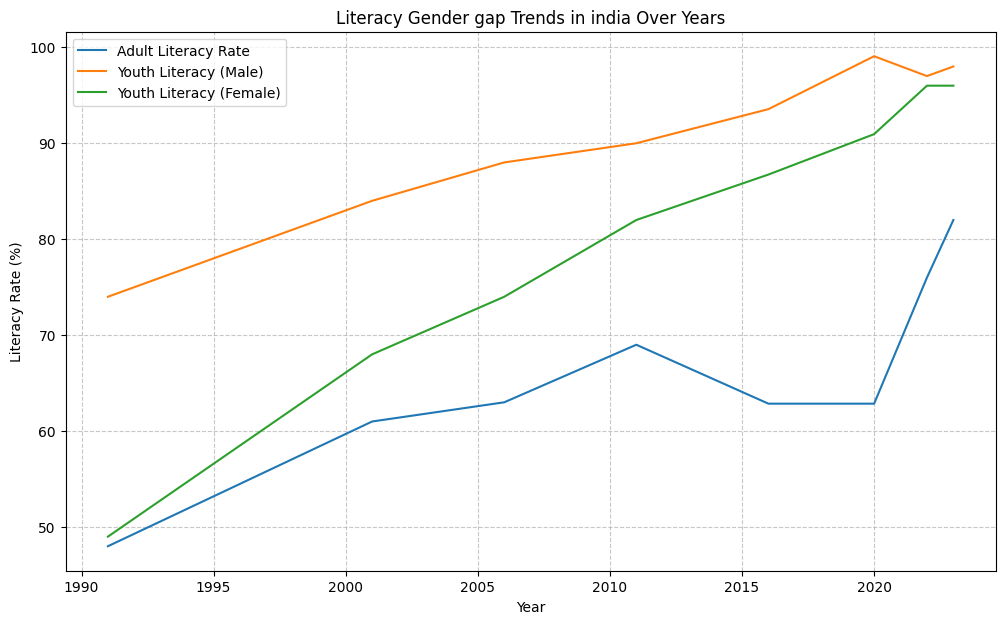

In [ ]:

country= input("enter the country name")
df= df_literacy[df_literacy['country'] == f'{country}']

plt.figure(figsize=(12, 7))
sns.lineplot(data=df, x='year', y='adult_literacy_rate', label='Adult Literacy Rate')
sns.lineplot(data=df, x='year', y='youth_literacy_male', label='Youth Literacy (Male)')
sns.lineplot(data=df, x='year', y='youth_literacy_female', label='Youth Literacy (Female)')

plt.title(f'Literacy Gender gap Trends in {country} Over Years')
plt.xlabel('Year')
plt.ylabel('Literacy Rate (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**2.ADULT LITTERACY RATE**

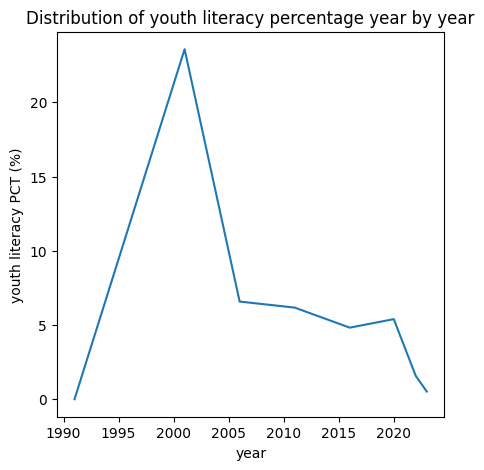

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))
sns.lineplot(data=df_literacy, x="year", y= df_literacy["youth_literacy_PCT"][df_literacy["country"]== "india"])
plt.title("Distribution of youth literacy percentage year by year")
plt.ylabel("youth literacy PCT (%)")
plt.xlabel("year")
plt.show()

**3.AVERGAE YOUTH LITERACY RATE DISTRIBUTION**

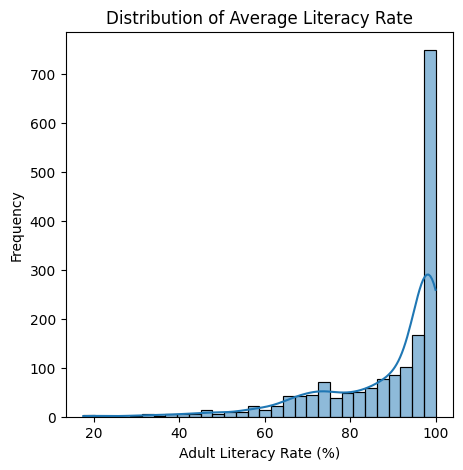

In [ ]:
plt.figure(figsize=(5,5))
sns.histplot(df_literacy["youth_literacy_average"], bins=30, kde=True)
plt.title("Distribution of Average Literacy Rate")
plt.xlabel("Adult Literacy Rate (%)")
plt.ylabel("Frequency")
plt.show()

**4.YOUTH LITERACY PERCENTAGE CHANGE OVER THE YEARS**

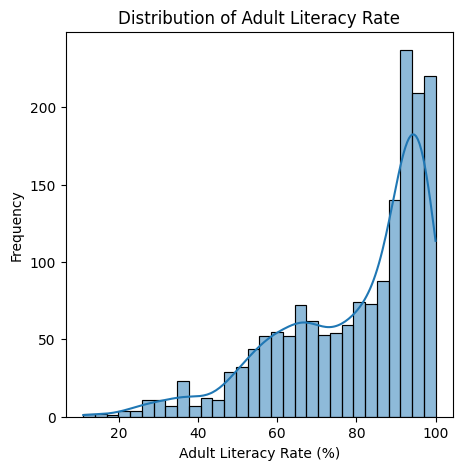

In [ ]:
plt.figure(figsize=(5,5))
sns.histplot(df_literacy["adult_literacy_rate"], bins=30, kde=True)
plt.title("Distribution of Adult Literacy Rate")
plt.xlabel("Adult Literacy Rate (%)")
plt.ylabel("Frequency")
plt.show()

**5.ILLITERACY RATE DISTRIBUTION**

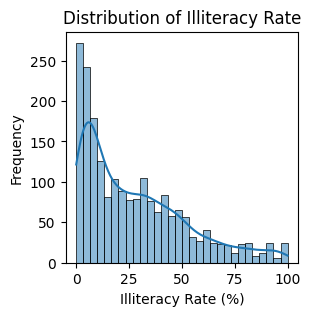

In [ ]:
plt.figure(figsize=(3,3))
sns.histplot(df_illiteracy["illiteracy_rate"], bins=30, kde=True)
plt.title("Distribution of Illiteracy Rate")
plt.xlabel("Illiteracy Rate (%)")
plt.ylabel("Frequency")
plt.show()

**6.YOUTH LITERACY RATE COMPARISION BETWEEN THE COUNTRIES**

enter the country name/tafghanistan
enter the country nameindia


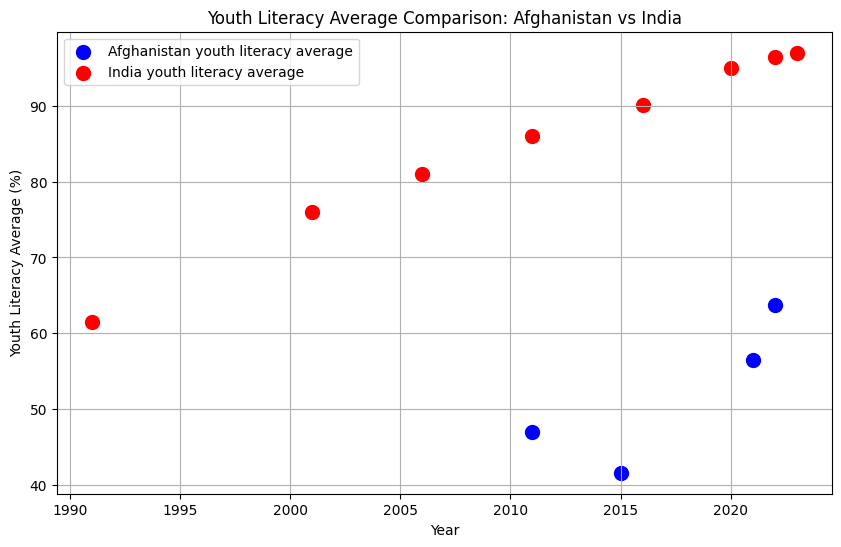

In [ ]:
coutnry1 = input("enter the country name")
df1 = df_literacy[df_literacy['country'] == f'{coutnry1}']
country2 = input("enter the country name")
df2= df_literacy[df_literacy['country'] == f'{country2}']

plt.figure(figsize=(10,6))
# Plot youth_literacy_average against year for the first country
plt.scatter(df1['year'], df1['youth_literacy_average'], label=f'{coutnry1.capitalize()} youth literacy average', color='blue', s=100)
# Plot youth_literacy_average against year for the second country
plt.scatter(df2['year'], df2['youth_literacy_average'], label=f'{country2.capitalize()} youth literacy average', color='red', s=100)

plt.xlabel("Year")
plt.ylabel("Youth Literacy Average (%)")
plt.title(f'Youth Literacy Average Comparison: {coutnry1.capitalize()} vs {country2.capitalize()}')
plt.legend()
plt.grid(True)
plt.show()

**7.BOX PLOT FOR THE LIERACY RATE FOR ALL OVER THE WORLD**

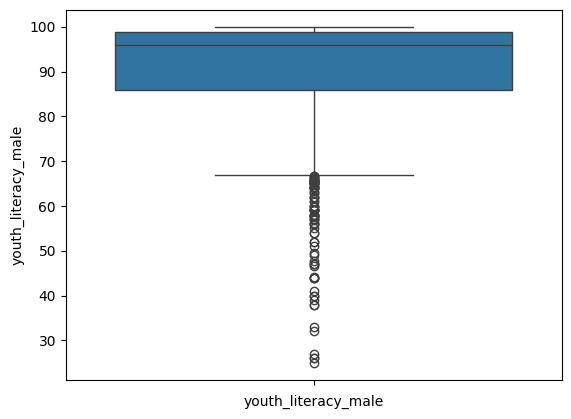

**8.REGION WISE CATAGORIZED VISUALIZE**

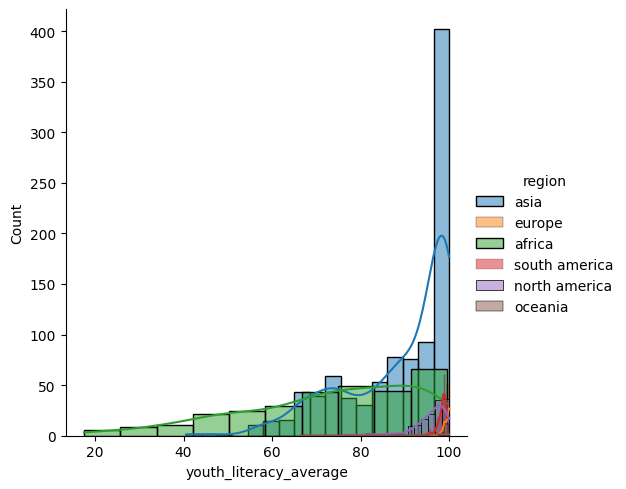

In [ ]:
sns.FacetGrid(df_literacy, hue="region", height=5).map(sns.histplot,"youth_literacy_average",kde=True).add_legend();
plt.show();

9.REGION WISE AVERGAE LITERACY DISTRIBUTION**

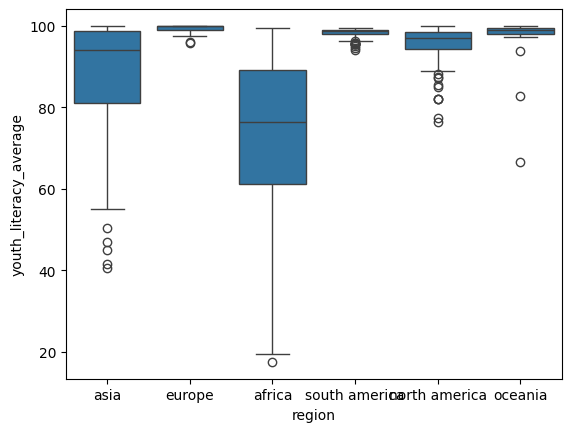

In [ ]:
sns.boxplot(x='region',y='youth_literacy_average',data=df_literacy)
plt.show()

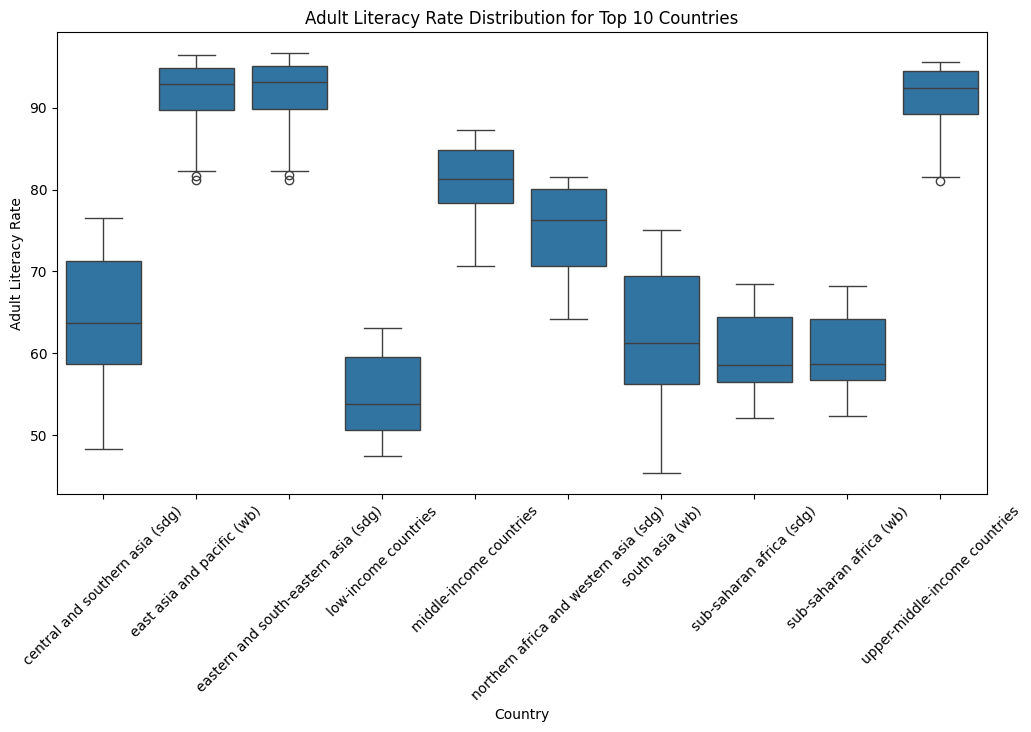

In [ ]:
# Get top 10 countries with most records
top10_countries = df_literacy['country'].value_counts().nlargest(10).index

# Filter dataframe
df_top10 = df_literacy[df_literacy['country'].isin(top10_countries)]

# Plot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top10,
    x='country',
    y='adult_literacy_rate'
)

plt.xticks(rotation=45)
plt.title("Adult Literacy Rate Distribution for Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Adult Literacy Rate")

plt.show()

In [ ]:
import pandas as pd
df_GDP_schooling=pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")
df_GDP_schooling

,country,year,literacy_rate,Average_years_of_education,Population_historical,region,GDP_PCAP,Total_GDP,GDP_per_year_of_Education,Education index
0,afghanistan,2000,33.917947,3.030000,20130334.0,asia,1617.8264,3.256739e+10,533.936106,0.279852
1,afghanistan,2005,33.917947,3.320000,24404575.0,asia,1908.1147,4.656673e+10,574.733343,0.290405
2,afghanistan,2010,33.917947,3.930000,28284088.0,asia,2848.5862,8.056966e+10,724.831094,0.312603
3,afghanistan,2011,31.000000,3.605714,29347708.0,asia,2757.0525,8.091317e+10,764.634212,0.286212
4,afghanistan,2015,33.753840,4.810000,33831767.0,asia,2967.6921,1.004023e+11,616.983805,0.343806
...,...,...,...,...,...,...,...,...,...,...
1487,zimbabwe,2005,88.613775,7.650000,12483433.0,africa,4004.6646,4.999196e+10,523.485569,0.721453
1488,zimbabwe,2010,88.613775,7.860000,13356551.0,africa,3885.3938,5.189546e+10,494.324911,0.729095
1489,zimbabwe,2015,88.613775,8.030000,14399008.0,africa,5102.7144,7.347403e+10,635.456339,0.735281
1490,zimbabwe,2019,93.227550,7.420000,15271377.0,africa,4993.8438,7.626287e+10,673.024771,0.736152


**10.GDP DISTRIBUTION**

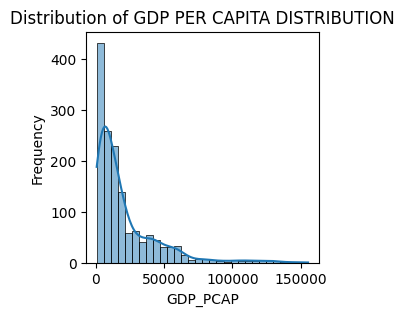

In [ ]:
plt.figure(figsize=(3,3))
sns.histplot(df_GDP_schooling["GDP_PCAP"], bins=30, kde=True)
plt.title("Distribution of GDP PER CAPITA DISTRIBUTION")
plt.xlabel("GDP_PCAP")
plt.ylabel("Frequency")
plt.show()

**11.LITERACY RATE VS GDP_PCAP**

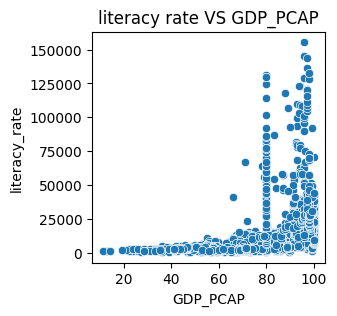

In [ ]:
plt.figure(figsize=(3,3))
sns.scatterplot(data=df_GDP_schooling, y="GDP_PCAP", x="literacy_rate")
plt.title("literacy rate VS GDP_PCAP")
plt.xlabel("GDP_PCAP")
plt.ylabel("literacy_rate")
plt.show()

**12EDUCATION INDEX TREND WITH AVERGAE YEARS OF SCHOOLING**

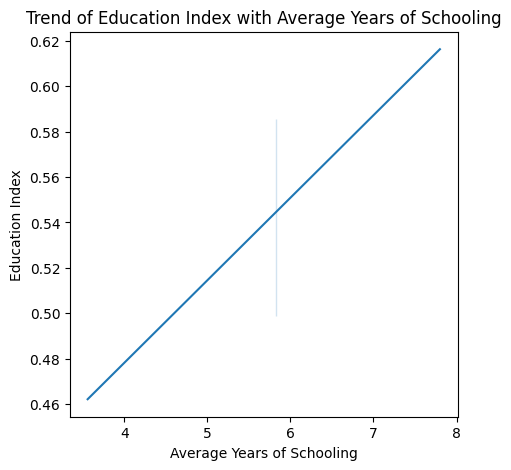

In [ ]:
plt.figure(figsize=(5,5))
sns.lineplot(data=df_GDP_schooling[df_GDP_schooling["country"]=="india"], x ="Average_years_of_education", y="Education index")
plt.title("Trend of Education Index with Average Years of Schooling")
plt.xlabel("Average Years of Schooling")
plt.ylabel("Education Index")
plt.show()

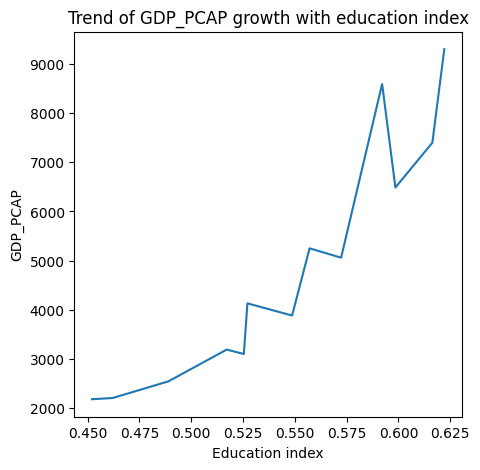

In [ ]:
plt.figure(figsize=(5,5))
sns.lineplot(data=df_GDP_schooling[df_GDP_schooling["country"]=="india"], x="Education index", y="GDP_PCAP")
plt.title("Trend of GDP_PCAP growth with education index")
plt.xlabel("Education index")
plt.ylabel("GDP_PCAP")
plt.show()

<Axes: >

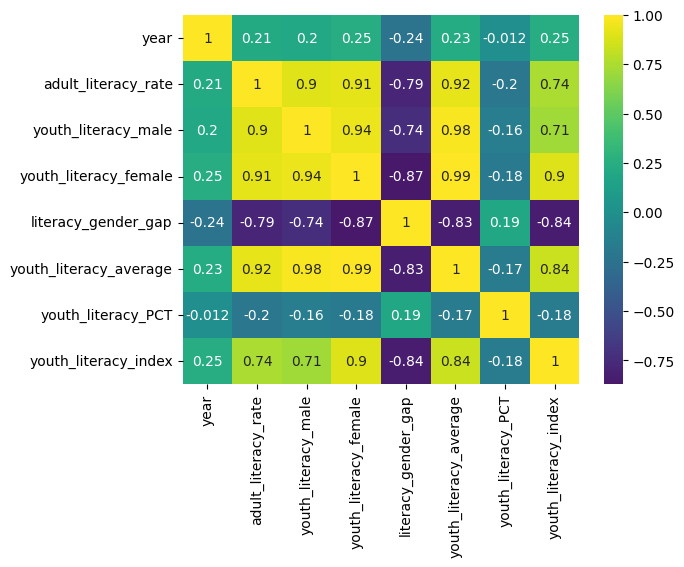

In [ ]:
sns.heatmap(df_literacy.select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)

In [ ]:
df_GDP= pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_cleaned.csv")
df_GDP

,country,year,GDP_PCAP,region
0,afghanistan,2000,1617.8264,asia
1,afghanistan,2001,1454.1108,asia
2,afghanistan,2002,1774.3087,asia
3,afghanistan,2003,1815.9282,asia
4,afghanistan,2004,1776.9182,asia
...,...,...,...,...
7235,zimbabwe,2020,4527.7197,africa
7236,zimbabwe,2021,4827.0890,africa
7237,zimbabwe,2022,5036.7610,africa
7238,zimbabwe,2023,5218.0225,africa


In [ ]:
df_GDP[df_GDP["country"]=="india"]

,country,year,GDP_PCAP,region
2929,india,1990,2203.1470,asia
2930,india,1991,2178.6860,asia
2931,india,1992,2249.6980,asia
2932,india,1993,2307.6072,asia
2933,india,1994,2411.4626,asia
2934,india,1995,2542.4220,asia
2935,india,1996,2680.2788,asia
2936,india,1997,2734.5210,asia
2937,india,1998,2847.9624,asia
2938,india,1999,3041.4827,asia


**13GDP TREND OVER THE YEARS**

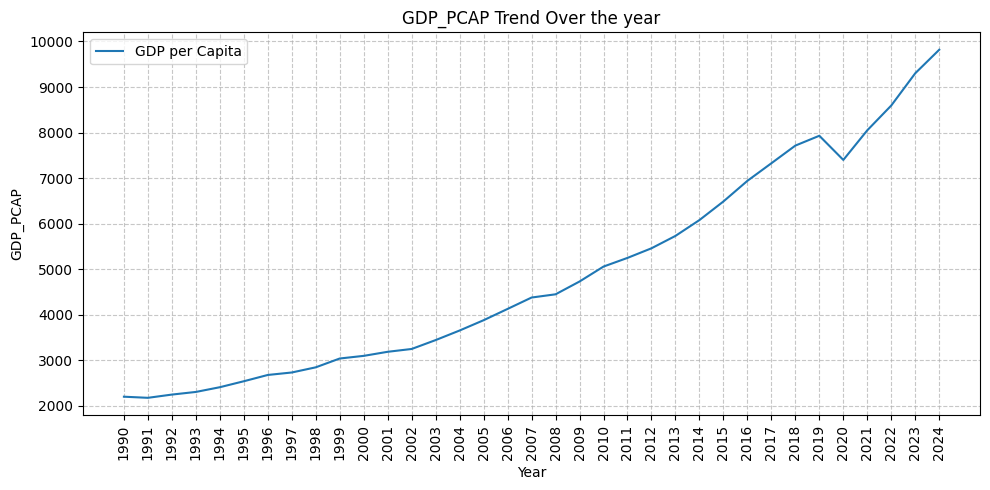

In [ ]:
from ipywidgets import Label
df_GDP= pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_cleaned.csv")
plt.figure(figsize=(10,5))
india_gdp_data = df_GDP[df_GDP["country"]=="india"]
sns.lineplot(data=india_gdp_data, x="year", y ="GDP_PCAP", label='GDP per Capita')
plt.title('GDP_PCAP Trend Over the year')
plt.xlabel('Year')
plt.ylabel('GDP_PCAP')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(india_gdp_data['year'].unique(), rotation=90)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

**its cleraed from above trend there is a GDP goes to down during the covid pandamic periods**

<Axes: >

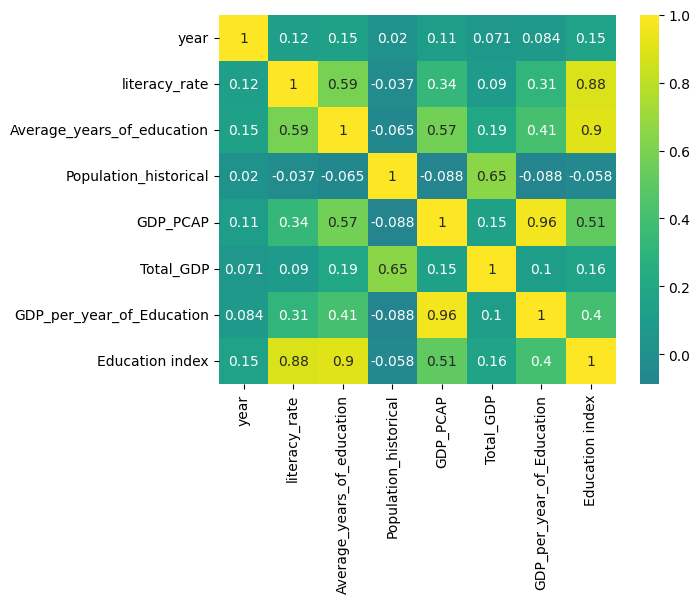

In [ ]:
sns.heatmap(df_GDP_schooling.select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)

In [ ]:

#df_illiteracy=df_illiteracy.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])
df_illiteracy.to_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv",index= False)

In [ ]:
df_illiteracy= pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")
df_illiteracy

,Unnamed: 0,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT,youth_literacy_index,Youth_literacy_ratio
0,0,afghanistan,2011,31.000000,62.00000,32.00000,asia,30.00000,47.000000,0.000000,0.516129,1.937500
1,1,afghanistan,2015,33.753840,57.73505,25.48416,asia,32.25089,41.609605,-11.468926,0.441398,2.265527
2,2,afghanistan,2021,37.000000,71.00000,42.00000,asia,29.00000,56.500000,35.785956,0.591549,1.690476
3,3,afghanistan,2022,66.411953,83.40000,44.17171,asia,39.22829,63.785855,12.895319,0.529637,1.888086
4,4,albania,2001,99.000000,99.00000,99.00000,europe,0.00000,99.000000,0.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1695,1695,zambia,2018,71.132300,82.44786,72.90992,africa,9.53794,77.678890,-12.720348,0.884315,1.130818
1696,1696,zimbabwe,1992,84.000000,97.00000,94.00000,africa,3.00000,95.500000,0.000000,0.969072,1.031915
1697,1697,zimbabwe,2009,85.075850,93.92461,95.65000,africa,1.72539,94.787305,-0.746277,1.018370,0.981961
1698,1698,zimbabwe,2014,85.075850,93.92461,96.31000,africa,2.38539,95.117305,0.348148,1.025397,0.975232


**3.world overall literacy and illiteracy rate through the history**

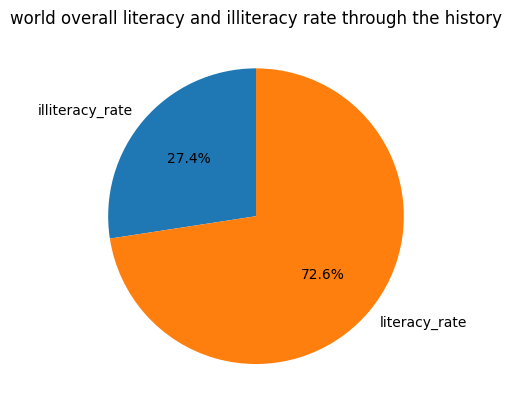

In [ ]:
categories =["illiteracy_rate","literacy_rate"]
world_Avg_literacy = [df_illiteracy["illiteracy_rate"].mean(),df_illiteracy["literacy_rate"].mean()]
world_Avg_literacy
plt.pie(world_Avg_literacy,labels=categories,autopct='%1.1f%%',startangle=90)
plt.title('world overall literacy and illiteracy rate through the history')
plt.show()

In [ ]:
#df_literacy["Youth_literacy_ratio"]= df_literacy["youth_literacy_male"]/df_literacy["youth_literacy_female"]
df_literacy.to_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")

**SQL WORK**

In [ ]:
connection = sqlite3.connect("/content/drive/MyDrive/A Global Literacy/Untitled Folderliteracy_final.db", timeout=10)
cursor = connection.cursor()

In [ ]:
df_illiteracy.to_sql("df_illiteracy_rate", if_exists ="replace", con = connection, index = False)
connection.commit()

In [ ]:
df_GDP_schooling.to_sql("df_GDP_schooling", if_exists ="replace", con = connection, index = False)
connection.commit()

In [ ]:
cursor.execute("SELECT name,sql FROM sqlite_master WHERE type ='table'")
row= cursor.fetchall()
for i in row:
  print(i)

('literacy_rate', 'CREATE TABLE literacy_rate (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    adult_literacy_rate DECIMAL(18,6),\n    youth_literacy_male DECIMAL(18,6),\n    youth_literacy_female DECIMAL(18,6),\n    region VARCHAR(50),\n    literacy_gender_gap DECIMAL(18,6),\n    youth_literacy_average DECIMAL(18,6),\n    youth_literacy_ratio DECIMAL(18,6),\n    youth_literacy_PCT DECIMAL(18,6),\n    youth_literacy_index DECIMAL(18,6),\n    PRIMARY KEY (country, year)\n)')
('illiteracy_rate', 'CREATE TABLE illiteracy_rate (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    illiteracy_rate DECIMAL(18,6),\n    literacy_rate DECIMAL(18,6),\n    literacy_gap DECIMAL(18,6),\n    PRIMARY KEY (country, year)\n   )')
('gdp_schooling', 'CREATE TABLE gdp_schooling (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    literacy_rate DECIMAL(18,6),\n    Average_years_of_education DECIMAL(18,6),\n    Population_historical DECIMAL(18,6),\n    region VARCHAR(50),\n    GDP_PCAP DECI

In [ ]:
cursor.execute ('''
CREATE TABLE IF NOT EXISTS literacy_rate (
    country VARCHAR(255) NOT NULL,
    year INT,
    adult_literacy_rate DECIMAL(18,6),
    youth_literacy_male DECIMAL(18,6),
    youth_literacy_female DECIMAL(18,6),
    region VARCHAR(50),
    literacy_gender_gap DECIMAL(18,6),
    youth_literacy_average DECIMAL(18,6),
    youth_literacy_ratio DECIMAL(18,6),
    youth_literacy_PCT DECIMAL(18,6),
    youth_literacy_index DECIMAL(18,6),
    PRIMARY KEY (country, year)
)
''')

connection.commit()

In [ ]:
cursor.execute("DROP TABLE df_literacy_rate")

In [ ]:
cursor.execute("""
               INSERT
               INTO
               literacy_rate(country, year, adult_literacy_rate, youth_literacy_male, youth_literacy_female, region,literacy_gender_gap,youth_literacy_average,youth_literacy_ratio,youth_literacy_PCT,youth_literacy_index ) SELECT country, year, adult_literacy_rate, youth_literacy_male, youth_literacy_female, region,literacy_gender_gap,youth_literacy_average,youth_literacy_ratio,youth_literacy_PCT,youth_literacy_index FROM df_literacy_rate """)

In [ ]:
cursor.execute("SELECT * FROM literacy_rate")
row= cursor.fetchall()
for i in row:
  print(i)

('afghanistan', 2011, 31, 62, 32, 'asia', 30, 47, 1.9375, 0, 0.5161290322580645)
('afghanistan', 2015, 33.75384, 57.73505, 25.48416, 'asia', 32.25089, 41.609605, 2.2655268998468068, -11.468925531914886, 0.4413984226219601)
('afghanistan', 2021, 37, 71, 42, 'asia', 29, 56.5, 1.6904761904761905, 35.78595615122997, 0.5915492957746479)
('afghanistan', 2022, 66.41195333333333, 83.4, 44.17171, 'asia', 39.22829000000001, 63.785855, 1.8880862887128438, 12.895318584070804, 0.5296368105515586)
('albania', 2001, 99, 99, 99, 'europe', 0, 99, 1, 0, 1)
('albania', 2005, 99, 98.23499833333334, 99.49, 'europe', 1.255001666666658, 98.86249916666668, 0.9873856501490939, -0.1388897306397352, 1.0127755045346278)
('albania', 2008, 96, 99, 99, 'europe', 0, 99, 1, 0.1390829025083917, 1)
('albania', 2009, 99.68928571428572, 94.82, 96.61, 'europe', 1.7900000000000065, 95.715, 0.981471897319118, -3.31818181818182, 1.018877873866273)
('albania', 2011, 97, 99, 99, 'europe', 0, 99, 1, 3.43206393982134, 1)
('albani

In [ ]:
cursor.execute ('''
CREATE TABLE IF NOT EXISTS illiteracy_rate (
    country VARCHAR(255) NOT NULL,
    year INT,
    illiteracy_rate DECIMAL(18,6),
    literacy_rate DECIMAL(18,6),
    literacy_gap DECIMAL(18,6),
    PRIMARY KEY (country, year)
   )
''')

connection.commit()

In [ ]:
cursor.execute("""
               INSERT
               INTO
               illiteracy_rate(country, year, illiteracy_rate, literacy_rate,literacy_gap) SELECT country, year, illiteracy_rate, literacy_rate,literacy_gap FROM df_illiteracy_rate """)

In [ ]:
cursor.execute("SELECT * FROM illiteracy_rate")
row= cursor.fetchall()
for i in row:
  print(i)

('Afghanistan', 1950, 97, 3, 94)
('Afghanistan', 1979, 82, 18, 64)
('Afghanistan', 2011, 69, 31, 38)
('Afghanistan', 2015, 66.246155, 33.75384, 32.492315000000005)
('Afghanistan', 2021, 63, 37, 26)
('Albania', 1950, 27.5, 72.5, 45)
('Albania', 2001, 1, 99, 98)
('Albania', 2008, 4, 96, 92)
('Albania', 2011, 3, 97, 94)
('Albania', 2012, 3, 97, 94)
('Albania', 2017, 1.1837692, 98.81623, 97.6324608)
('Algeria', 1950, 82.5, 17.5, 65)
('Algeria', 1987, 50, 50, 0)
('Algeria', 2002, 30, 70, 40)
('Algeria', 2006, 27, 73, 46)
('Algeria', 2008, 25, 75, 50)
('American Samoa', 1950, 3.5, 96.5, 93)
('American Samoa', 1980, 3, 97, 94)
('Andorra', 1950, 17.5, 82.5, 65)
('Angola', 1950, 97, 3, 94)
('Angola', 2001, 33, 67, 34)
('Angola', 2014, 34, 66, 32)
('Angola', 2015, 33.764137, 66.23586, 32.471723000000004)
('Anguilla', 1984, 5, 95, 90)
('Antigua and Barbuda', 1950, 17.5, 82.5, 65)
('Antigua and Barbuda', 2001, 1, 99, 98)
('Argentina', 1914, 35.1, 64.9, 29.800000000000004)
('Argentina', 1947, 13.6,

In [ ]:
cursor.execute("DROP TABLE df_illiteracy_rate")

In [ ]:
cursor.execute("DROP TABLE gdp_schooling")

In [ ]:
cursor.execute ('''
CREATE TABLE IF NOT EXISTS gdp_schooling (
    country VARCHAR(255) NOT NULL,
    year INT,
    literacy_rate DECIMAL(18,6),
    Average_years_of_education DECIMAL(18,6),
    Population_historical DECIMAL(18,6),
    region VARCHAR(50),
    GDP_PCAP DECIMAL(18,6),
    GDP_per_year_of_Education DECIMAL(18,6),
    Total_GDP DECIMAL(18,6),
    Education_index DECIMAL(18,6),
    PRIMARY KEY (country, year)
)
''')

connection.commit()

In [ ]:
cursor.execute("""
               INSERT
               INTO
               gdp_schooling(country, year, literacy_rate,   Average_years_of_education, Population_historical, region, GDP_PCAP, GDP_per_year_of_Education, Total_GDP, Education_index) SELECT country, year, literacy_rate,   Average_years_of_education, Population_historical, region, GDP_PCAP, GDP_per_year_of_Education, Total_GDP, Education_index FROM df_GDP_schooling""")
connection.commit()

In [ ]:
cursor.execute("SELECT * FROM gdp_schooling")
row= cursor.fetchall()
for i in row:
  print(i)

('afghanistan', 2000, 33.917946666666666, 3.03, 20130334, 'asia', 1617.8264, 533.9361056105611, 32567385786.0176, 0.2798517420669578)
('afghanistan', 2005, 33.917946666666666, 3.32, 24404575, 'asia', 1908.1147, 574.733343373494, 46566728304.7525, 0.2904048716157205)
('afghanistan', 2010, 33.917946666666666, 3.93, 28284088, 'asia', 2848.5862, 724.8310941475827, 80569662756.3856, 0.3126028337700145)
('afghanistan', 2011, 31, 3.605714285714285, 29347708, 'asia', 2757.0525, 764.6342115689382, 80913171710.67, 0.2862123102516115)
('afghanistan', 2015, 33.75384, 4.81, 33831767, 'asia', 2967.6921, 616.9838045738047, 100402267654.9407, 0.3438055901018922)
('afghanistan', 2020, 33.917946666666666, 5.69, 39068977, 'asia', 2769.6858, 486.7637609841828, 108208790817.4266, 0.3766494131004366)
('afghanistan', 2021, 37, 3.605714285714285, 40000410, 'asia', 2144.1665, 594.6579041204437, 85767539108.265, 0.3162123102516115)
('albania', 1990, 97.563246, 8.61, 3277965, 'europe', 5560.857, 645.860278745644

In [ ]:
cursor.execute("DROP TABLE df_GDP_schooling")

In [ ]:
cursor.execute("SELECT name,sql FROM sqlite_master WHERE type ='table'")
row= cursor.fetchall()
for i in row:
  print(i)

('literacy_rate', 'CREATE TABLE literacy_rate (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    adult_literacy_rate DECIMAL(18,6),\n    youth_literacy_male DECIMAL(18,6),\n    youth_literacy_female DECIMAL(18,6),\n    region VARCHAR(50),\n    literacy_gender_gap DECIMAL(18,6),\n    youth_literacy_average DECIMAL(18,6),\n    youth_literacy_ratio DECIMAL(18,6),\n    youth_literacy_PCT DECIMAL(18,6),\n    youth_literacy_index DECIMAL(18,6),\n    PRIMARY KEY (country, year)\n)')
('illiteracy_rate', 'CREATE TABLE illiteracy_rate (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    illiteracy_rate DECIMAL(18,6),\n    literacy_rate DECIMAL(18,6),\n    literacy_gap DECIMAL(18,6),\n    PRIMARY KEY (country, year)\n   )')
('gdp_schooling', 'CREATE TABLE gdp_schooling (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    literacy_rate DECIMAL(18,6),\n    Average_years_of_education DECIMAL(18,6),\n    Population_historical DECIMAL(18,6),\n    region VARCHAR(50),\n    GDP_PCAP DECI

In [ ]:
## 1.Get top 5 countries with highest adult literacy in 2020.
cursor.execute("SELECT country, year, adult_literacy_rate FROM literacy_rate WHERE year = 2020 ORDER BY adult_literacy_rate DESC LIMIT 5")

curows = cursor.fetchall()
for row in curows:
    print(row)

('armenia', 2020, 100)
('brazil', 2020, 99.25)
('mongolia', 2020, 99)
('spain', 2020, 99)
('north america (wb)', 2020, 98.77029)


In [ ]:
#2. Find countries where female youth literacy < 80%.
cursor.execute(" SELECT country, year, youth_literacy_female FROM literacy_rate WHERE youth_literacy_female < 80")
row = cursor.fetchall()
for row in row:
    print(row)

('afghanistan', 2011, 32)
('afghanistan', 2015, 25.48416)
('afghanistan', 2021, 42)
('afghanistan', 2022, 44.17171)
('angola', 2001, 63)
('angola', 2014, 71)
('angola', 2015, 67.4276)
('bangladesh', 1991, 38)
('bangladesh', 2001, 60)
('bangladesh', 2007, 77.09)
('bangladesh', 2012, 79)
('belize', 1991, 78)
('benin', 1992, 27)
('benin', 2001, 31.85)
('benin', 2002, 33)
('benin', 2006, 39.53)
('benin', 2017, 50.98536)
('benin', 2019, 62.76271)
('benin', 2021, 59.18644)
('benin', 2022, 67.93813)
('bhutan', 2005, 68)
('bhutan', 2010, 63.34)
('burkina faso', 1991, 14)
('burkina faso', 1996, 14)
('burkina faso', 2003, 25)
('burkina faso', 2005, 26)
('burkina faso', 2006, 27)
('burkina faso', 2007, 33)
('burkina faso', 2010, 27.24)
('burkina faso', 2014, 44)
('burkina faso', 2018, 54)
('burkina faso', 2019, 44)
('burkina faso', 2021, 58.758)
('burkina faso', 2022, 60.56925)
('burundi', 1990, 48)
('burundi', 2000, 70)
('burundi', 2005, 52.83)
('burundi', 2008, 57)
('burundi', 2010, 66.51)
('bu

In [ ]:
#3.Average adult literacy per continent (owid region)
cursor.execute("SELECT region, AVG(adult_literacy_rate) AS AVG_adult_literacy FROM literacy_rate Group BY region")
row = cursor.fetchall()
for i in row:
  print (i)

('africa', 60.60957322987437)
('asia', 80.43826359408287)
('europe', 96.162319141252)
('north america', 87.53412752250772)
('oceania', 93.4458661111111)
('south america', 91.929839569193)


In [ ]:
#4. Countries with illiteracy % > 20% in 2000.
cursor.execute("SELECT country, illiteracy_rate FROM illiteracy_rate Where year = 2000 AND illiteracy_rate>20")
row = cursor.fetchall()
for i in row:
  print(i)

('Burundi', 41)
('Cameroon', 32)
('Central African Republic', 49)
('Central and Southern Asia (SDG)', 39.91697)
('Chad', 74)
('Comoros', 32)
("Cote d'Ivoire", 51)
('Gambia', 63)
('Ghana', 42)
('Guinea-Bissau', 59)
('Iraq', 26)
('Laos', 30)
('Low-income countries', 48.60134)
('Lower-middle-income countries', 37.19769)
('Madagascar', 29)
('Mauritania', 49)
('Middle East and North Africa (WB)', 30.598412)
('Middle-income countries', 21.022774)
('Northern Africa and Western Asia (SDG)', 27.835136)
('Oceania (excluding Australia and New Zealand) (SDG)', 34.64868)
('Papua New Guinea', 43)
('Rwanda', 35)
('Saudi Arabia', 21)
('South Asia (WB)', 42.34942)
('Sub-Saharan Africa (SDG)', 43.6094)
('Sub-Saharan Africa (WB)', 43.37245)
('Sudan', 39)
('Togo', 47)


In [ ]:
#5. Trend of illiteracy % for India (2000–2020).
cursor.execute("SELECT country, year, illiteracy_rate FROM illiteracy_rate WHERE country = 'India' AND year BETWEEN 2000 AND 2020")
row = cursor.fetchall()
for i in row:
  print(i)

('India', 2001, 39)
('India', 2006, 37)
('India', 2011, 31)


In [ ]:
#6.Top 10 countries with largest illiterate population in the last year.
cursor.execute("SELECT country, illiteracy_rate FROM illiteracy_rate WHERE year = (SELECT MAX(year) FROM illiteracy_rate) ORDER BY illiteracy_rate DESC LIMIT 10")
row = cursor.fetchall()
for i in row:
  print(i)

NameError: name 'cursor' is not defined

In [ ]:
#7. Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000.
cursor.execute("SELECT country, Average_years_of_education, GDP_PCAP FROM gdp_schooling WHERE Average_years_of_education>7 AND GDP_PCAP < 5000 ORDER BY GDP_PCAP DESC")
row = cursor.fetchall()
for i in row:
  print(i)


('zimbabwe', 7.42, 4993.8438)
('palestine', 7.940288984980912, 4984.8057)
('kyrgyzstan', 11.115, 4969.9614)
('sao tome and principe', 7.940288984980912, 4919.5527)
('palestine', 7.940288984980912, 4769.5234)
('cameroon', 7.37, 4763.482)
('philippines', 7.96, 4740.439)
('palestine', 7.940288984980912, 4714.3735)
('cameroon', 7.05, 4698.667)
('syria', 7.92, 4633.3496)
('sri lanka', 8.9, 4561.579)
('zimbabwe', 8.32, 4527.7197)
('east timor', 7.940288984980912, 4515.423)
('philippines', 7.15, 4504.4624)
('palestine', 7.940288984980912, 4503.0806)
('ghana', 7.66, 4495.689)
('turkmenistan', 7.940288984980912, 4493.4277)
('philippines', 7.59, 4477.323)
('philippines', 8.314285714285715, 4374.0674)
('vietnam', 8.17, 4349.2236)
('palestine', 7.940288984980912, 4311.5386)
('marshall islands', 7.940288984980912, 4259.116)
('vietnam', 8.17, 4119.0537)
('china', 7.79, 4066.0364)
('east timor', 7.940288984980912, 4047.2495)
('east timor', 7.940288984980912, 4038.336)
('zimbabwe', 7.65, 4004.6646)
('

In [ ]:
#8.Rank countries by GDP per schooling for the year 2020.
cursor.execute("SELECT country,GDP_per_year_of_Education, RANK() OVER (ORDER BY GDP_per_year_of_Education DESC) AS RANK_Country FROM gdp_schooling WHERE year =2020")
row = cursor.fetchall()
for i in row:
  print(i)


('qatar', 12096.467136150235, 1)
('luxembourg', 11263.28100607112, 2)
('singapore', 8873.89280245023, 3)
('brunei', 8650.959051724138, 4)
('kuwait', 7458.129909365559, 5)
('ireland', 7421.292212518194, 6)
('norway', 7127.156870860927, 7)
('united arab emirates', 6981.050156739811, 8)
('bahrain', 6554.719366626065, 9)
('switzerland', 5961.826522744796, 10)
('saudi arabia', 5823.603853955376, 11)
('austria', 5801.387295476419, 12)
('denmark', 5623.989734816083, 13)
('netherlands', 5487.494923857868, 14)
('macao', 5438.694986326344, 15)
('united states', 5055.7109609609615, 16)
('sweden', 5027.272673931266, 17)
('finland', 5015.82443438914, 18)
('belgium', 4955.362402765773, 19)
('hong kong', 4780.087840997662, 20)
('oman', 4730.381988747012, 21)
('germany', 4595.670992366412, 22)
('australia', 4428.49690641918, 23)
('iceland', 4400.873022912047, 24)
('new zealand', 4279.962534690101, 25)
('canada', 4183.517401392111, 26)
('malta', 4167.727047146402, 27)
('france', 4147.294533221194, 28)


In [ ]:
#9.Find global average schooling years per year.
cursor.execute("SELECT year, AVG(Average_years_of_education) AS Avg_year_of_education  FROM gdp_schooling GROUP BY year")
row = cursor.fetchall()
for i in row:
  print(i)

(1990, 6.78119796302717)
(1991, 8.266274002946163)
(1992, 8.424126984126984)
(1993, 8.738465103388085)
(1994, 6.954668302014265)
(1995, 7.233660083194268)
(1996, 8.415965103388084)
(1997, 6.146762994993637)
(1998, 3.962571428571428)
(1999, 8.779572882213738)
(2000, 7.726490789766259)
(2001, 8.237404392017073)
(2002, 7.228874526761337)
(2003, 7.220179934218238)
(2004, 7.3373658061862335)
(2005, 8.132373812097702)
(2006, 7.251936871347086)
(2007, 7.749175451132618)
(2008, 7.501434225844439)
(2009, 7.482185669732622)
(2010, 8.609640685295158)
(2011, 8.21352889849809)
(2012, 7.304338948361148)
(2013, 7.517452926068248)
(2014, 7.334185946965502)
(2015, 8.931973127668021)
(2016, 7.723592459724257)
(2017, 7.293927091302851)
(2018, 7.14806699982113)
(2019, 7.529260828035888)
(2020, 9.321192852936795)
(2021, 7.509601735592057)
(2022, 7.355171336038083)
(2023, 7.6203939473745885)


In [ ]:
#10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling(less than 6).
cursor.execute("SELECT country,GDP_PCAP,Average_years_of_education FROM gdp_schooling WHERE year = 2020 AND Average_years_of_education <6 ORDER BY GDP_PCAP DESC LIMIT 10")
row = cursor.fetchall()
for i in row:
  print(i)



('cambodia', 6128.782, 5.81)
('mauritania', 5963.2354, 5.55)
('papua new guinea', 4077.6313, 4.84)
('senegal', 4018.0413, 4.4)
('sudan', 3401.2498, 4.38)
('haiti', 3239.8354, 5.95)
('mali', 2796.4104, 3.55)
('afghanistan', 2769.6858, 5.69)
('sierra leone', 2752.6262, 4.99)
('gambia', 2702.319, 4.92)


In [ ]:
#11.Show countries where the illiterate population is high despite having more than 10 average years of schooling.
cursor.execute("""SELECT
                  il.country AS country,
                  il.illiteracy_rate,
                  gd.Average_years_of_education
                  FROM
                  illiteracy_rate AS il
                  JOIN gdp_schooling AS gd
                  ON
                  LOWER(il.country) = LOWER(gd.country)
                  WHERE
                  gd.Average_years_of_education >= 5 AND il.illiteracy_rate
                  GROUP BY
                  il.country
                  ORDER BY il.illiteracy_rate DESC LIMIT 5 """)
row = cursor.fetchall()
for i in row:
    print(i)

('Ireland', 100, 10.64)
('Poland', 100, 9.75)
('Sweden', 99, 11.03)
('Afghanistan', 97, 5.69)
('Angola', 97, 7.940288984980912)


In [ ]:
#12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years. (country of your choice)

cursor.execute("""
             SELECT
             gd.year,
             gd.GDP_PCAP,
             lr.adult_literacy_rate
             FROM gdp_schooling gd
             INNER JOIN literacy_rate lr ON LOWER(gd.country) = LOWER(lr.country) AND gd.year = lr.year
             WHERE LOWER(gd.country) = 'india' AND gd.year >= (SELECT MAX(year) - 20 FROM gdp_schooling)
             ORDER BY
             gd.year
             """)
# Fetch and print results to verify the fix
rows = cursor.fetchall()
for row in rows:
    print(row)

(2006, 4129.7783, 63)
(2011, 5249.5493, 69)
(2020, 7399.531, 62.85714285714285)
(2022, 8594.392, 76)
(2023, 9301.756, 82)


In [ ]:
#13.Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000 in 2020.
cursor.execute ("""
    SELECT
        lr.country,
        lr.year,
        ABS(lr.youth_literacy_male - lr.youth_literacy_female) AS youth_literacy_difference,
        dg.GDP_PCAP
    FROM
        literacy_rate lr
    INNER JOIN
        gdp_schooling dg ON LOWER(lr.country) = LOWER(dg.country) AND lr.year = dg.year
    WHERE
        dg.year = 2020 AND dg.GDP_PCAP > 30000
    ORDER BY
        youth_literacy_difference DESC
""")
rows = cursor.fetchall()
for i in rows:
    print(i)

('kuwait', 2020, 1, 49372.82)
('saudi arabia', 2020, 1, 57420.734)
('spain', 2020, 1, 41553.45)
('oman', 2020, 0, 37560.6)
('singapore', 2020, 0, 115893.04)


In [ ]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
!pkill -f cloudflared
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 > nohup.out 2>&1 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.1 MB/s eta 0:00:00
--2026-03-29 11:25:20--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64 [following]
--2026-03-29 11:25:20--  https://github.com/cloudflare/cloudflared/releases/download/2026.3.0/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/731ab2f8-6b77-4adb-a7b3-1104525e9d72?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-29T12%3A19%3A50Z&rscd=attachment%3B+filename%3Dclou

In [ ]:
!pkill -f streamlit
!streamlit run "/content/drive/MyDrive/global literacy projects/Global_literacy.py" &>/content/logs.txt &

In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your new tunnel URL is: {}"

Your new tunnel URL is: https://discussion-supports-bool-certificates.trycloudflare.com


In [ ]:
!pip install streamlit streamlit_option_menu  # installing streamlit and streamlit_option_menu packages

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 14.2 MB/s eta 0:00:00


In [ ]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://discussion-supports-bool-certificates.trycloudflare.com


In [ ]:
%%writefile "/content/drive/MyDrive/global literacy projects/Global_literacy.py"
import streamlit as st
import pandas as pd
from datetime import date, timedelta

from streamlit_option_menu import option_menu
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Must be the first Streamlit command used
st.set_page_config(layout="wide")

connection = sqlite3.connect("/content/drive/MyDrive/A Global Literacy/Untitled Folderliteracy_final.db")
cursor = connection.cursor()

with st.sidebar:
    selected = option_menu("Navigation", ["Queries","Visualizations","country Profile"],
        icons=['Search','search','radio',], menu_icon="cast", default_index=0)



if selected == "Queries":
     st.title("GLOBAL LITERACY ANALYSIS")
     st.write("Global GDP & Literacy |SQL Powered analysis")
     option = st.selectbox(
    "Select a query",
    ("1.Get top 5 countries with highest adult literacy in 2020",
     "2.Find countries where female youth literacy < 80%",
     "3.Average adult literacy per continent (owid region)",
     "4.Countries with illiteracy % > 20% in 2000",
     "5.Trend of illiteracy % for India (2000–2020)",
     "6.Top 10 countries with largest illiterate population in the last year",
     "7.Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000",
     "8.Rank countries by GDP per schooling for the year 2020",
     "9.Find global average schooling years per year",
     "10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling",
     "11.Show countries where the illiterate population is high despite having more than 10 average years of schooling",
     "12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years",
     "13.Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000"
     ),
     key='main_query_selector'
     )
     if option == "1.Get top 5 countries with highest adult literacy in 2020":
         df = pd.read_sql("SELECT country, year, adult_literacy_rate FROM literacy_rate WHERE year = 2020 ORDER BY adult_literacy_rate DESC LIMIT 5",con = connection)
         st.dataframe(df)

     if option == "2.Find countries where female youth literacy < 80%":
         df = pd.read_sql(" SELECT country, year, youth_literacy_female FROM literacy_rate WHERE youth_literacy_female < 80",con = connection)
         st.dataframe(df)

     if option == "3.Average adult literacy per continent (owid region)":
         df = pd.read_sql("SELECT region, AVG(adult_literacy_rate) AS AVG_adult_literacy FROM literacy_rate Group BY region",con = connection)
         st.dataframe(df)

     if option == "4.Countries with illiteracy % > 20% in 2000":
         df = pd.read_sql("SELECT country, illiteracy_rate FROM illiteracy_rate Where year = 2000 AND illiteracy_rate>20",con = connection)
         st.dataframe(df)

     if option == "5.Trend of illiteracy % for India (2000–2020)":
         df = pd.read_sql("SELECT country, year, illiteracy_rate FROM illiteracy_rate WHERE country = 'India' AND year BETWEEN 2000 AND 2020",con = connection)
         st.dataframe(df)

     if option == "6.Top 10 countries with largest illiterate population in the last year":
         df = pd.read_sql("SELECT country, illiteracy_rate FROM illiteracy_rate WHERE year = (SELECT MAX(year) FROM illiteracy_rate) ORDER BY illiteracy_rate DESC LIMIT 10",con = connection)
         st.dataframe(df)

     if option == "7.Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000":
         df = pd.read_sql("SELECT country, Average_years_of_education, GDP_PCAP FROM gdp_schooling WHERE Average_years_of_education>7 AND GDP_PCAP < 5000",con = connection)
         st.dataframe(df)

     if option == "8.Rank countries by GDP per schooling for the year 2020":
         df = pd.read_sql("SELECT country,GDP_per_year_of_Education, RANK() OVER (ORDER BY GDP_per_year_of_Education DESC) AS RANK_Country FROM gdp_schooling WHERE year =2020",con = connection)
         st.dataframe(df)

     if option == "9.Find global average schooling years per year":
         df = pd.read_sql("SELECT year, AVG(Average_years_of_education) AS Avg_year_of_education  FROM gdp_schooling GROUP BY year",con = connection)
         st.dataframe(df)

     if option == "10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling":
         df = pd.read_sql("SELECT country,GDP_PCAP,Average_years_of_education FROM gdp_schooling WHERE year = 2020 AND Average_years_of_education <6 ORDER BY GDP_PCAP DESC LIMIT 10",con = connection)
         st.dataframe(df)

     if option == "11.Show countries where the illiterate population is high despite having more than 10 average years of schooling":
         df = pd.read_sql("""SELECT
                  il.country AS country,
                  il.illiteracy_rate,
                  gd.Average_years_of_education
                  FROM
                  illiteracy_rate AS il
                  JOIN gdp_schooling AS gd
                  ON
                  LOWER(il.country) = LOWER(gd.country)
                  WHERE
                  gd.Average_years_of_education >= 5 AND il.illiteracy_rate
                  GROUP BY
                  il.country
                  ORDER BY il.illiteracy_rate DESC LIMIT 5 """,con = connection)
         st.dataframe(df)

     if option == "12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years":
         df = pd.read_sql("""
             SELECT
             gd.year,
             gd.GDP_PCAP,
             lr.adult_literacy_rate
             FROM gdp_schooling gd
             INNER JOIN literacy_rate lr ON LOWER(gd.country) = LOWER(lr.country) AND gd.year = lr.year
             WHERE LOWER(gd.country) = 'india' AND gd.year >= (SELECT MAX(year) - 20 FROM gdp_schooling)
             ORDER BY
             gd.year
             """,con = connection)
         st.dataframe(df)


     if option == "13.Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000":
         df = pd.read_sql("""
                      SELECT
                      lr.country,
                      lr.year,
                      ABS(lr.youth_literacy_male - lr.youth_literacy_female) AS youth_literacy_difference,
                      dg.GDP_PCAP
                      FROM
                      literacy_rate lr
                      INNER JOIN
                      gdp_schooling dg ON LOWER(lr.country) = LOWER(dg.country) AND lr.year = dg.year
                      WHERE
                      dg.year = 2020 AND dg.GDP_PCAP > 30000
                      ORDER BY
                      youth_literacy_difference DESC
                      """,con = connection)
         st.dataframe(df)

if selected == "Visualizations":
     st.title("EDA Visualization")
     st.write("")
     option = st.selectbox(
    "Select a query",
    ("Describes of the Literacy_rate Data Frame",
     "Describes of the Iliteracy_rate Data Frame",
     "Describes of the GDP Schooling Data Frame",
     "Country Wise youth Literacy Average Comparison",
     "1.COMPARISION OF ALL LITERACY RATE OVER THE YEARS",
     "2.TOP 10 lowest Literacy rate countries",
     "3.TOP 10 highest illiteracy rate countries",
     "4.TOP 10 countries with highest GDP & Education Index to desired the investment",
     "5.Youth literacy percentage distribution",
     "6.Distribution of Average Literacy Rate",
     "7.Distribution of Adult Literacy Rate",
     "8.Distribution of illiteracy Rate",
     "9.BOX Plot for different Regions",
     "10.Adult Literacy Rate Distribution for Top 10 countries",
     "11.GDP Distribution rate",
     "12.Literacy Rate VS GDP",
     "13.India GDP Trend Over the Years",
     "14.Correlation MAP fo the GDP_Schooling datas",
     "15.India Correlation MAP fo the GDP_Schooling datas",
     "16.Correlation MAP fo the literacy_rate datas",
     "17.India Correlation MAP for the literacy_rate datas"
     ),
     key='vis_query_selector'
     )
     if option == "Describes of the Literacy_rate Data Frame":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
         df=df_literacy.describe()
         st.dataframe(df)
     if option == "Describes of the Iliteracy_rate Data Frame":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")
         df=df_literacy.describe()
         st.dataframe(df)
     if option == "Describes of the GDP Schooling Data Frame":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")
         df=df_literacy.describe()
         st.dataframe(df)

     if option == "Country Wise youth Literacy Average Comparison":
         country_1=pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
         selected_country_1 = st.selectbox("Select a country", country_1, key='country_compare_1')
         country_2=pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
         selected_country_2 = st.selectbox("Select a country", country_2, key='country_compare_2')
         st.write(f"You selected countries: {selected_country_1},{selected_country_2}")
         df_literacy_data = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv") # Load literacy data once
         df1 = df_literacy_data[df_literacy_data['country'] == f'{selected_country_1}']
         df2= df_literacy_data[df_literacy_data['country'] == f'{selected_country_2}']

         fig = plt.figure(figsize=(10,6))
         # Plot youth_literacy_average against year for the first country
         plt.scatter(df1['year'], df1['youth_literacy_average'], label=f'{selected_country_1.capitalize()} youth literacy average', color='blue', s=100)
         # Plot youth_literacy_average against year for the second country
         plt.scatter(df2['year'], df2['youth_literacy_average'], label=f'{selected_country_2.capitalize()} youth literacy average', color='red', s=100)

         plt.xlabel("Year")
         plt.ylabel("Youth Literacy Average (%)")
         plt.title(f'Youth Literacy Average Comparison: {selected_country_1.capitalize()} vs {selected_country_2.capitalize()}')
         plt.legend()
         plt.grid(True)
         st.pyplot(fig)


     if option == "1.COMPARISION OF ALL LITERACY RATE OVER THE YEARS":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
         #country= input("enter the country name")
         #df= df_literacy[df_literacy['country'] == f'{country}']
         df= df_literacy[df_literacy['country'] == 'india']
         country = 'india' # Define country for the plot title

         fig=plt.figure(figsize=(12, 7))
         sns.lineplot(data=df, x='year', y='adult_literacy_rate', label='Adult Literacy Rate')
         sns.lineplot(data=df, x='year', y='youth_literacy_male', label='Youth Literacy (Male)')
         sns.lineplot(data=df, x='year', y='youth_literacy_female', label='Youth Literacy (Female)')

         plt.title(f'Literacy Gender gap Trends in {country} Over Years')
         plt.xlabel('Year')
         plt.ylabel('Literacy Rate (%)')
         plt.legend()
         plt.grid(True, linestyle='--', alpha=0.7)
         st.pyplot(fig)
     if option =="2.TOP 10 lowest Literacy rate countries":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        df=df_literacy.groupby("country")["adult_literacy_rate"].mean().reset_index()
        df_lowest_literacy = df.sort_values(by='adult_literacy_rate', ascending=True).reset_index()
        df_lowest_literacy=df_lowest_literacy.head(10)
        st.dataframe(df_lowest_literacy)

        fig=plt.figure(figsize=(10,6))
        plt.bar(df_lowest_literacy["country"], df_lowest_literacy["adult_literacy_rate"])
        plt.xlabel("country")
        plt.ylabel("literacy rate")
        plt.title("10 lowest literacy rate")
        plt.xticks(rotation=45)
        st.pyplot(fig)
     if option =="3.TOP 10 highest illiteracy rate countries":
        df_illiteracy=pd.read_sql("SELECT * FROM illiteracy_rate",con =connection)
        df_avg_illiteracy = df_illiteracy.groupby("country")["illiteracy_rate"].mean().reset_index()
        df_high_illiteracy = df_avg_illiteracy.sort_values(by='illiteracy_rate', ascending=False).head(10)
        st.dataframe(df_high_illiteracy)

        fig=plt.figure(figsize=(10,6))
        plt.bar(df_high_illiteracy["country"], df_high_illiteracy["illiteracy_rate"])
        plt.xlabel("country")
        plt.ylabel("illiteracy rate")
        plt.title("10 highest illiteracy rate")
        plt.xticks(rotation=45)
        st.pyplot(fig)

     if option =="4.TOP 10 countries with highest GDP & Education Index to desired the investment":
        GDP_school =pd.read_sql("SELECT * FROM gdp_schooling", con = connection)
        gdp_education_data = GDP_school.groupby("country")[["GDP_PCAP", "Education_index"]].mean().reset_index()
        gdp_education_data1 =gdp_education_data.sort_values(by="GDP_PCAP", ascending=False).head(10)
        #st.dataframe(gdp_education_data1)

        fig=plt.figure(figsize=(10,6))
        sns.scatterplot(data=gdp_education_data1, x= gdp_education_data1["Education_index"], y=gdp_education_data1["GDP_PCAP"], hue = "country",legend= True)
        plt.xlabel("EDUCATION INDEX")
        plt.ylabel("GDP_PCAP")
        plt.title("COMPARISON OF GDP_PCAP & EDUCATION INDEX")
        plt.xticks(rotation=45)
        st.pyplot(fig)
     if option =="5.Youth literacy percentage distribution":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(3,3))
        sns.lineplot(data=df_literacy, x="year", y= df_literacy["youth_literacy_PCT"][df_literacy["country"]== "india"])
        plt.title("Distribution of youth literacy percentage year by year")
        plt.ylabel("youth literacy PCT (%)")
        plt.xlabel("year")
        st.pyplot(fig)
     if option == "6.Distribution of Average Literacy Rate":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(3,3))
        sns.histplot(df_literacy["youth_literacy_average"], bins=30, kde=True)
        plt.title("Distribution of Average Literacy Rate")
        plt.xlabel("Adult Literacy Rate (%)")
        plt.ylabel("Frequency")
        st.pyplot(fig)
     if option == "7.Distribution of Adult Literacy Rate":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(5,5))
        sns.histplot(df_literacy["adult_literacy_rate"], bins=30, kde=True)
        plt.title("Distribution of Adult Literacy Rate")
        plt.xlabel("Adult Literacy Rate (%)")
        plt.ylabel("Frequency")
        st.pyplot(fig)
     if option == "8.Distribution of illiteracy Rate":
        df_illiteracy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")
        fig=plt.figure(figsize=(3,3))
        sns.histplot(df_illiteracy["illiteracy_rate"], bins=30, kde=True)
        plt.title("Distribution of Illiteracy Rate")
        plt.xlabel("Illiteracy Rate (%)")
        plt.ylabel("Frequency")
        st.pyplot(fig)

     if option == "9.BOX Plot for different Regions":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(3,3))
        sns.boxplot(x='region',y='youth_literacy_average',data=df_literacy)
        plt.title("Box Plot for different Regions")
        plt.xlabel("Region")
        plt.ylabel("Average Literacy Rate")
        plt.xticks(rotation=45)
        st.pyplot(fig)
     if option == "10.Adult Literacy Rate Distribution for Top 10 countries":
       df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
       top10_countries = df_literacy['country'].value_counts().nlargest(10).index
       df_top10 = df_literacy[df_literacy['country'].isin(top10_countries)]
       fig=plt.figure(figsize=(10,6))
       sns.boxplot(data=df_top10,
       x='country',
       y='adult_literacy_rate'
       )
       plt.xticks(rotation=45)
       plt.title("Adult Literacy Rate Distribution for Top 10 Countries")
       plt.xlabel("Country")
       plt.ylabel("Adult Literacy Rate")
       st.pyplot(fig)

     if option == "11.GDP Distribution rate":
       GDP_school =pd.read_sql("SELECT * FROM GDP_schooling", con = connection)
       fig=plt.figure(figsize=(3,3))
       sns.histplot(GDP_school["GDP_PCAP"], bins=30, kde=True)
       plt.title("Distribution of GDP PER CAPITA DISTRIBUTION")
       plt.xlabel("GDP_PCAP")
       plt.ylabel("Frequency")
       st.pyplot(fig)

     if option == "12.Literacy Rate VS GDP":
       GDP_school =pd.read_sql("SELECT * FROM GDP_schooling", con = connection)
       fig=plt.figure(figsize=(3,3))
       sns.scatterplot(data=GDP_school, y="GDP_PCAP", x="literacy_rate")
       plt.title("literacy rate VS GDP_PCAP")
       plt.xlabel("GDP_PCAP")
       plt.ylabel("literacy_rate")
       st.pyplot(fig)

     if option == "13.India GDP Trend Over the Years":
       df_GDP= pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_cleaned.csv")
       fig =plt.figure(figsize=(10,5))
       india_gdp_data = df_GDP[df_GDP["country"]=="india"]
       sns.lineplot(data=india_gdp_data, x="year", y ="GDP_PCAP", label='GDP per Capita')
       plt.title('GDP_PCAP Trend Over the year')
       plt.xlabel('Year')
       plt.ylabel('GDP_PCAP')
       plt.legend()
       plt.grid(True, linestyle='--', alpha=0.7)
       plt.xticks(india_gdp_data['year'].unique(), rotation=90)
       plt.tight_layout() # Adjust layout to prevent labels from being cut off
       st.pyplot(fig)

     if option == "14.Correlation MAP fo the GDP_Schooling datas":
       GDP_school =pd.read_sql("SELECT * FROM GDP_schooling", con = connection)
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(GDP_school.select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)

     if option == "15.India Correlation MAP fo the GDP_Schooling datas":
       GDP_school =pd.read_sql("SELECT * FROM GDP_schooling", con = connection)
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(GDP_school[GDP_school["country"]=="india"].select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)

     if option == "16.Correlation MAP fo the literacy_rate datas":
       df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(df_literacy.select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)

     if option == "17.India Correlation MAP for the literacy_rate datas":
       df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(df_literacy[df_literacy["country"]=="india"].select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)



if selected == "country Profile":
     st.title("Tends of The GDP,illiteracy & literacy - Analysis Over the Years")
     st.write("Country Wise")

     country =pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
     selected_country = st.selectbox("Select a country", country, key='country_profile_selector')
     st.write(f"You selected: {selected_country}")
     data = pd.read_sql(f"""SELECT
                        li.country,
                        li.year,
                        li.adult_literacy_rate,
                        li.youth_literacy_average,
                        li.youth_literacy_male,
                        li.youth_literacy_female,
                        li.literacy_gender_gap,
                        li.youth_literacy_ratio,
                        il.illiteracy_rate,
                        li.youth_literacy_PCT,
                        li.youth_literacy_index,
                        gdp.Average_years_of_education,
                        gdp.Population_historical,
                        gdp.GDP_PCAP,
                        gdp.Total_GDP
                 FROM
                       literacy_rate li
                 JOIN
                       illiteracy_rate il ON li.year=il.year AND LOWER(li.country) = LOWER(il.country)
                 JOIN
                       gdp_schooling gdp ON li.year=gdp.year AND LOWER(li.country) = LOWER(gdp.country)
                 WHERE
                       LOWER(li.country) = '{selected_country}'
                       ORDER BY li.year""", con = connection)
     pd.options.display.float_format = "{:,.2f}".format
     st.dataframe(data)



Overwriting /content/drive/MyDrive/global literacy projects/Global_literacy.py


In [ ]:
cursor.execute("SELECT name,sql FROM sqlite_master WHERE type='table';")
rows = cursor.fetchall()
for row in rows:
    print(row)

('literacy_rate', 'CREATE TABLE literacy_rate (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    adult_literacy_rate DECIMAL(18,6),\n    youth_literacy_male DECIMAL(18,6),\n    youth_literacy_female DECIMAL(18,6),\n    region VARCHAR(50),\n    literacy_gender_gap DECIMAL(18,6),\n    youth_literacy_average DECIMAL(18,6),\n    youth_literacy_ratio DECIMAL(18,6),\n    youth_literacy_PCT DECIMAL(18,6),\n    youth_literacy_index DECIMAL(18,6),\n    PRIMARY KEY (country, year)\n)')
('illiteracy_rate', 'CREATE TABLE illiteracy_rate (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    illiteracy_rate DECIMAL(18,6),\n    literacy_rate DECIMAL(18,6),\n    literacy_gap DECIMAL(18,6),\n    PRIMARY KEY (country, year)\n   )')
('gdp_schooling', 'CREATE TABLE gdp_schooling (\n    country VARCHAR(255) NOT NULL,\n    year INT,\n    literacy_rate DECIMAL(18,6),\n    Average_years_of_education DECIMAL(18,6),\n    Population_historical DECIMAL(18,6),\n    region VARCHAR(50),\n    GDP_PCAP DECI

In [ ]:
selected_country = 'india'
data = pd.read_sql(f"""SELECT
    li.country,
    li.year,
    li.adult_literacy_rate,
    li.youth_literacy_average,
    li.youth_literacy_male,
    li.youth_literacy_female,
    li.literacy_gender_gap,
    li.youth_literacy_ratio,
    il.illiteracy_rate,
    li.youth_literacy_PCT,
    li.youth_literacy_index,
    gdp.Average_years_of_education,
    gdp.Population_historical,
    gdp.GDP_PCAP,
    gdp.Total_GDP
FROM
    literacy_rate li
JOIN
    illiteracy_rate il ON li.year=il.year AND LOWER(li.country) = LOWER(il.country)
JOIN
    gdp_schooling gdp ON li.year=gdp.year AND LOWER(li.country) = LOWER(gdp.country)
WHERE
    LOWER(li.country) = '{selected_country}'
ORDER BY li.year""", con = connection)
pd.options.display.float_format = "{:,.2f}".format
data

,country,year,adult_literacy_rate,youth_literacy_average,youth_literacy_male,youth_literacy_female,literacy_gender_gap,youth_literacy_ratio,illiteracy_rate,youth_literacy_PCT,youth_literacy_index,Average_years_of_education,Population_historical,GDP_PCAP,Total_GDP
0,india,1991,48,61.50,74,49,25,1.51,52,0.00,0.66,5.83,883927605,"2,178.69","1,925,800,698,027.03"
1,india,2001,61,76.00,84,68,16,1.24,39,23.58,0.81,5.83,1077898579,"3,188.81","3,437,214,091,070.56"
2,india,2006,63,81.00,88,74,14,1.19,37,6.58,0.84,5.83,1172878888,"4,129.78","4,843,729,780,190.53"
3,india,2011,69,86.00,90,82,8,1.10,31,6.17,0.91,5.83,1261224956,"5,249.55","6,620,862,584,912.33"
4,india,2022,76,96.50,97,96,1,1.01,24,1.57,0.99,5.83,1425423209,"8,594.39","12,250,645,824,043.93"
5,india,2023,82,97.00,98,96,2,1.02,18,0.52,0.98,5.83,1438069597,"9,301.76","13,376,572,502,312.33"


In [ ]:
country =pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)
country

,country
0,afghanistan
1,albania
2,algeria
3,angola
4,argentina
...,...
174,vietnam
175,world
176,yemen
177,zambia


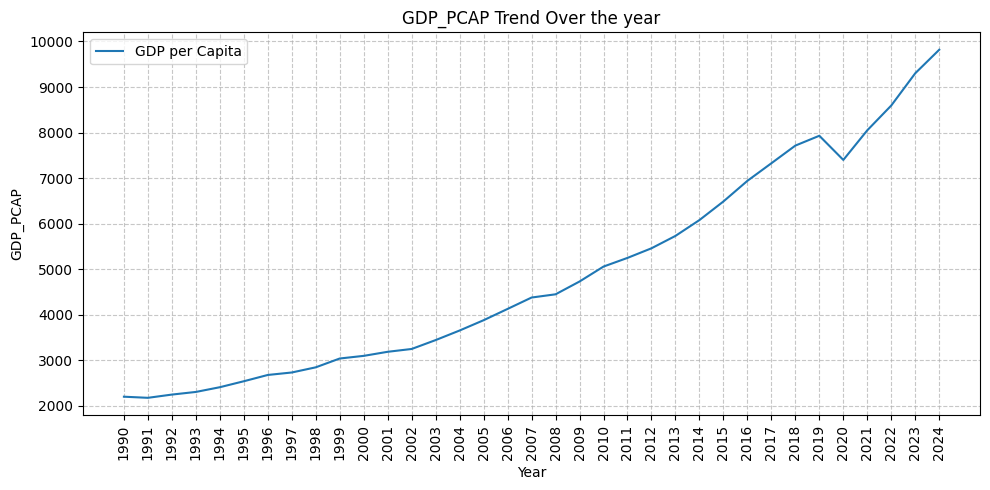

In [ ]:
from ipywidgets import Label
df_GDP= pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_cleaned.csv")
plt.figure(figsize=(10,5))
india_gdp_data = df_GDP[df_GDP["country"]=="india"]
sns.lineplot(data=india_gdp_data, x="year", y ="GDP_PCAP", label='GDP per Capita')
plt.title('GDP_PCAP Trend Over the year')
plt.xlabel('Year')
plt.ylabel('GDP_PCAP')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(india_gdp_data['year'].unique(), rotation=90)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

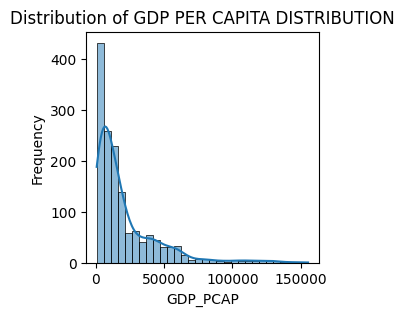

In [ ]:
plt.figure(figsize=(3,3))
sns.histplot(df_GDP_schooling["GDP_PCAP"], bins=30, kde=True)
plt.title("Distribution of GDP PER CAPITA DISTRIBUTION")
plt.xlabel("GDP_PCAP")
plt.ylabel("Frequency")
plt.show()

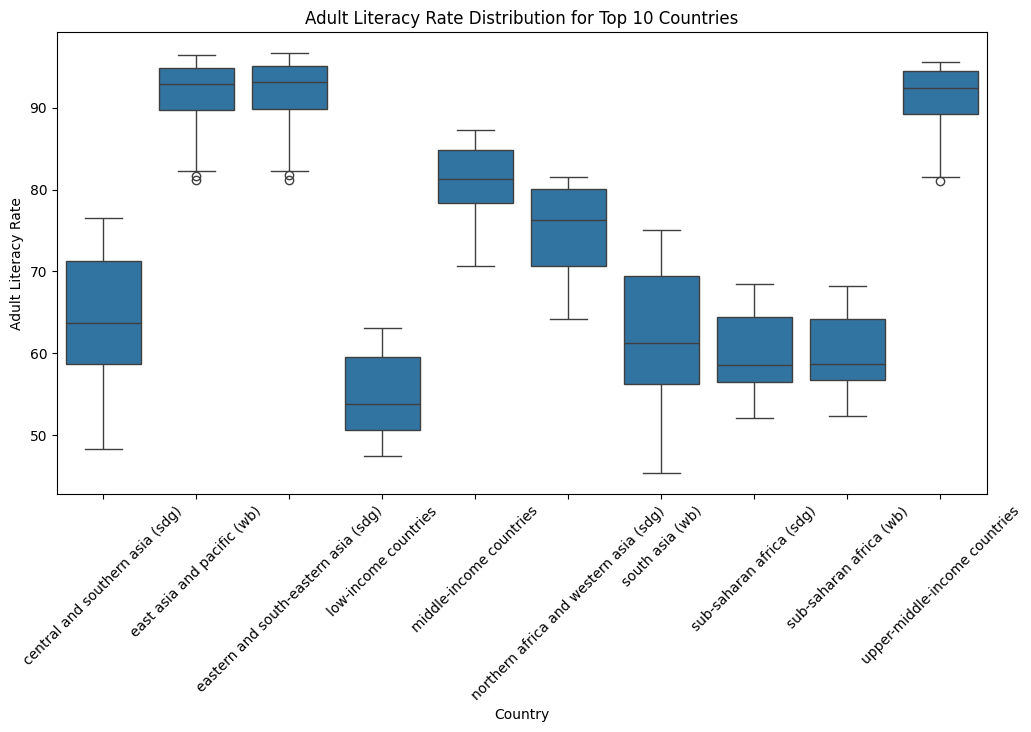

In [ ]:
# Get top 10 countries with most records
top10_countries = df_literacy['country'].value_counts().nlargest(10).index

# Filter dataframe
df_top10 = df_literacy[df_literacy['country'].isin(top10_countries)]

# Plot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top10,
    x='country',
    y='adult_literacy_rate'
)

plt.xticks(rotation=45)
plt.title("Adult Literacy Rate Distribution for Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Adult Literacy Rate")

plt.show()

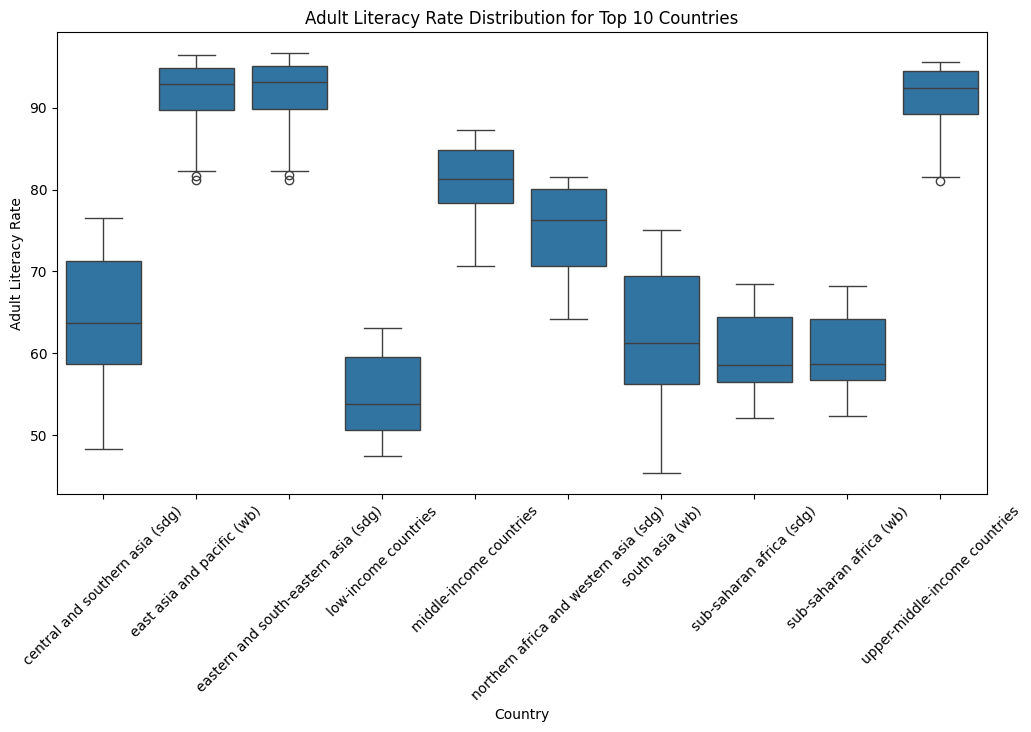

In [ ]:
# Get top 10 countries with most records
top10_countries = df_literacy['country'].value_counts().nlargest(10).index

# Filter dataframe
df_top10 = df_literacy[df_literacy['country'].isin(top10_countries)]

# Plot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_top10,
    x='country',
    y='adult_literacy_rate'
)

plt.xticks(rotation=45)
plt.title("Adult Literacy Rate Distribution for Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Adult Literacy Rate")

plt.show()

In [ ]:
GDP_school

,country,year,literacy_rate,Average_years_of_education,Population_historical,region,GDP_PCAP,GDP_per_year_of_Education,Total_GDP,Education_index
0,afghanistan,2000,33.917947,3.030000,20130334,asia,1617.8264,533.936106,3.256739e+10,0.279852
1,afghanistan,2005,33.917947,3.320000,24404575,asia,1908.1147,574.733343,4.656673e+10,0.290405
2,afghanistan,2010,33.917947,3.930000,28284088,asia,2848.5862,724.831094,8.056966e+10,0.312603
3,afghanistan,2011,31.000000,3.605714,29347708,asia,2757.0525,764.634212,8.091317e+10,0.286212
4,afghanistan,2015,33.753840,4.810000,33831767,asia,2967.6921,616.983805,1.004023e+11,0.343806
...,...,...,...,...,...,...,...,...,...,...
1487,zimbabwe,2005,88.613775,7.650000,12483433,africa,4004.6646,523.485569,4.999196e+10,0.721453
1488,zimbabwe,2010,88.613775,7.860000,13356551,africa,3885.3938,494.324911,5.189546e+10,0.729095
1489,zimbabwe,2015,88.613775,8.030000,14399008,africa,5102.7144,635.456339,7.347403e+10,0.735281
1490,zimbabwe,2019,93.227550,7.420000,15271377,africa,4993.8438,673.024771,7.626287e+10,0.736152


In [ ]:
df_literacy

,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT,youth_literacy_index
0,afghanistan,2011,31.000000,62.00000,32.00000,asia,30.00000,47.000000,0.000000,0.516129
1,afghanistan,2015,33.753840,57.73505,25.48416,asia,32.25089,41.609605,-11.468926,0.441398
2,afghanistan,2021,37.000000,71.00000,42.00000,asia,29.00000,56.500000,35.785956,0.591549
3,afghanistan,2022,66.411953,83.40000,44.17171,asia,39.22829,63.785855,12.895319,0.529637
4,albania,2001,99.000000,99.00000,99.00000,europe,0.00000,99.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
1695,zambia,2018,71.132300,82.44786,72.90992,africa,9.53794,77.678890,-12.720348,0.884315
1696,zimbabwe,1992,84.000000,97.00000,94.00000,africa,3.00000,95.500000,0.000000,0.969072
1697,zimbabwe,2009,85.075850,93.92461,95.65000,africa,1.72539,94.787305,-0.746277,1.018370
1698,zimbabwe,2014,85.075850,93.92461,96.31000,africa,2.38539,95.117305,0.348148,1.025397


In [ ]:
df=df_literacy.groupby("country")["adult_literacy_rate"].mean().reset_index()
df

,country,adult_literacy_rate
0,afghanistan,42.041448
1,albania,98.072217
2,algeria,63.824373
3,angola,66.411953
4,argentina,96.500000
...,...,...
174,vietnam,92.428571
175,world,82.325681
176,yemen,37.000000
177,zambia,71.226460


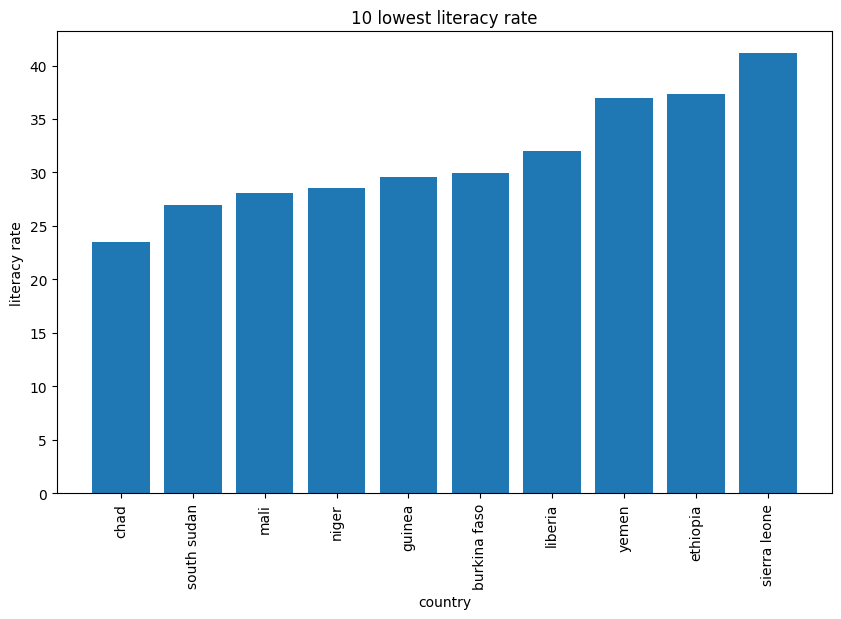

In [ ]:
df_lowest_literacy = df.sort_values(by='adult_literacy_rate', ascending=True).reset_index()
df_lowest_literacy=df_lowest_literacy.head(10)
df_lowest_literacy

plt.figure(figsize=(10,6))
plt.bar(df_lowest_literacy["country"], df_lowest_literacy["adult_literacy_rate"])
plt.xlabel("country")
plt.ylabel("literacy rate")
plt.title("10 lowest literacy rate")
plt.xticks(rotation=90)
plt.show()

In [ ]:
df_illiteracy

,country,year,illiteracy_rate,literacy_rate,literacy_gap
0,Afghanistan,1950,97.000000,3.00000,94.000000
1,Afghanistan,1979,82.000000,18.00000,64.000000
2,Afghanistan,2011,69.000000,31.00000,38.000000
3,Afghanistan,2015,66.246155,33.75384,32.492315
4,Afghanistan,2021,63.000000,37.00000,26.000000
...,...,...,...,...,...
2054,Zanzibar,1950,92.500000,7.50000,85.000000
2055,Zimbabwe,1950,77.500000,22.50000,55.000000
2056,Zimbabwe,1982,22.000000,78.00000,56.000000
2057,Zimbabwe,1992,16.000000,84.00000,68.000000


In [ ]:
df_illiteracy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiterate_rate")
df_illiteracy.to_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv",index=False)
#df_illiteracy=pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiterate_rate.csv")
#df_illiteracy


In [ ]:
#df_illiteracy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")
#df_illiteracy

,Unnamed: 0,country,year,illiteracy_rate,literacy_rate,literacy_gap
0,0,Afghanistan,1950,97.000000,3.00000,94.000000
1,1,Afghanistan,1979,82.000000,18.00000,64.000000
2,2,Afghanistan,2011,69.000000,31.00000,38.000000
3,3,Afghanistan,2015,66.246155,33.75384,32.492315
4,4,Afghanistan,2021,63.000000,37.00000,26.000000
...,...,...,...,...,...,...
2054,2054,Zanzibar,1950,92.500000,7.50000,85.000000
2055,2055,Zimbabwe,1950,77.500000,22.50000,55.000000
2056,2056,Zimbabwe,1982,22.000000,78.00000,56.000000
2057,2057,Zimbabwe,1992,16.000000,84.00000,68.000000


In [ ]:
df_illiteracy=pd.read_sql("SELECT * FROM illiteracy_rate",con =connection)
df_illiteracy

,country,year,illiteracy_rate,literacy_rate,literacy_gap
0,Afghanistan,1950,97.000000,3.00000,94.000000
1,Afghanistan,1979,82.000000,18.00000,64.000000
2,Afghanistan,2011,69.000000,31.00000,38.000000
3,Afghanistan,2015,66.246155,33.75384,32.492315
4,Afghanistan,2021,63.000000,37.00000,26.000000
...,...,...,...,...,...
2054,Zanzibar,1950,92.500000,7.50000,85.000000
2055,Zimbabwe,1950,77.500000,22.50000,55.000000
2056,Zimbabwe,1982,22.000000,78.00000,56.000000
2057,Zimbabwe,1992,16.000000,84.00000,68.000000


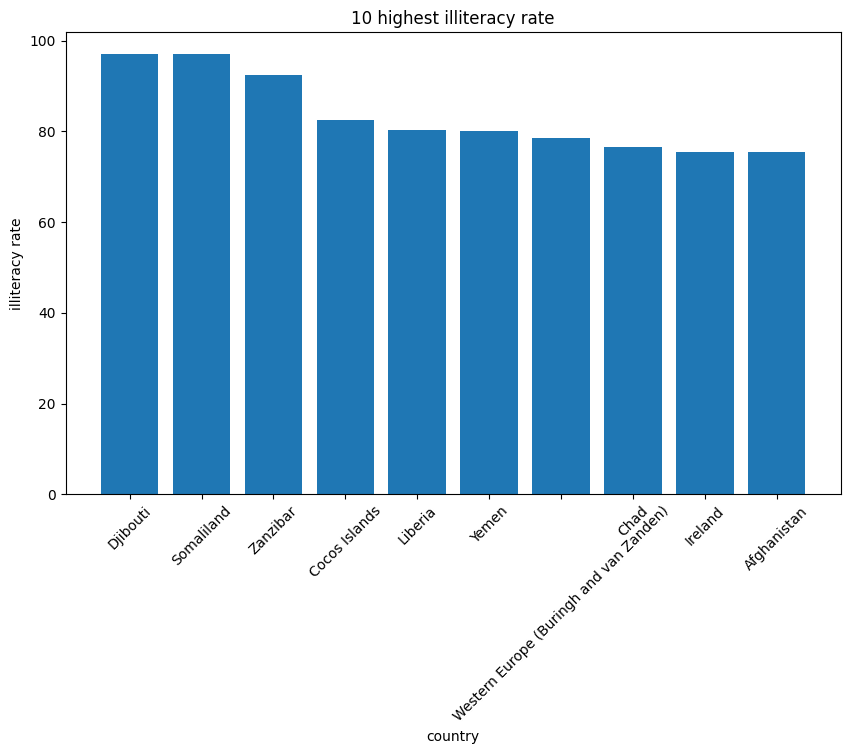

In [ ]:
df_illiteracy=pd.read_sql("SELECT * FROM illiteracy_rate",con =connection)
df_avg_illiteracy = df_illiteracy.groupby("country")["illiteracy_rate"].mean().reset_index()
df_high_illiteracy = df_avg_illiteracy.sort_values(by='illiteracy_rate', ascending=False).head(10)
df_high_illiteracy

plt.figure(figsize=(10,6))
plt.bar(df_high_illiteracy["country"], df_high_illiteracy["illiteracy_rate"])
plt.xlabel("country")
plt.ylabel("illiteracy rate")
plt.title("10 highest illiteracy rate")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df_high_illiteracy

,index,country,adult_literacy_rate
169,74,kazakhstan,99.666667
170,132,russia,99.666667
171,57,georgia,99.701522
172,171,uzbekistan,99.888889
173,82,latvia,100.000000
174,86,lithuania,100.000000
175,50,estonia,100.000000
176,115,north korea,100.000000
177,136,san marino,100.000000
178,144,slovenia,100.000000


In [ ]:
GDP_school =pd.read_sql("SELECT * FROM GDP_schooling", con = connection)
GDP_school

,country,year,literacy_rate,Average_years_of_education,Population_historical,region,GDP_PCAP,GDP_per_year_of_Education,Total_GDP,Education_index
0,afghanistan,2000,33.917947,3.030000,20130334,asia,1617.8264,533.936106,3.256739e+10,0.279852
1,afghanistan,2005,33.917947,3.320000,24404575,asia,1908.1147,574.733343,4.656673e+10,0.290405
2,afghanistan,2010,33.917947,3.930000,28284088,asia,2848.5862,724.831094,8.056966e+10,0.312603
3,afghanistan,2011,31.000000,3.605714,29347708,asia,2757.0525,764.634212,8.091317e+10,0.286212
4,afghanistan,2015,33.753840,4.810000,33831767,asia,2967.6921,616.983805,1.004023e+11,0.343806
...,...,...,...,...,...,...,...,...,...,...
1487,zimbabwe,2005,88.613775,7.650000,12483433,africa,4004.6646,523.485569,4.999196e+10,0.721453
1488,zimbabwe,2010,88.613775,7.860000,13356551,africa,3885.3938,494.324911,5.189546e+10,0.729095
1489,zimbabwe,2015,88.613775,8.030000,14399008,africa,5102.7144,635.456339,7.347403e+10,0.735281
1490,zimbabwe,2019,93.227550,7.420000,15271377,africa,4993.8438,673.024771,7.626287e+10,0.736152


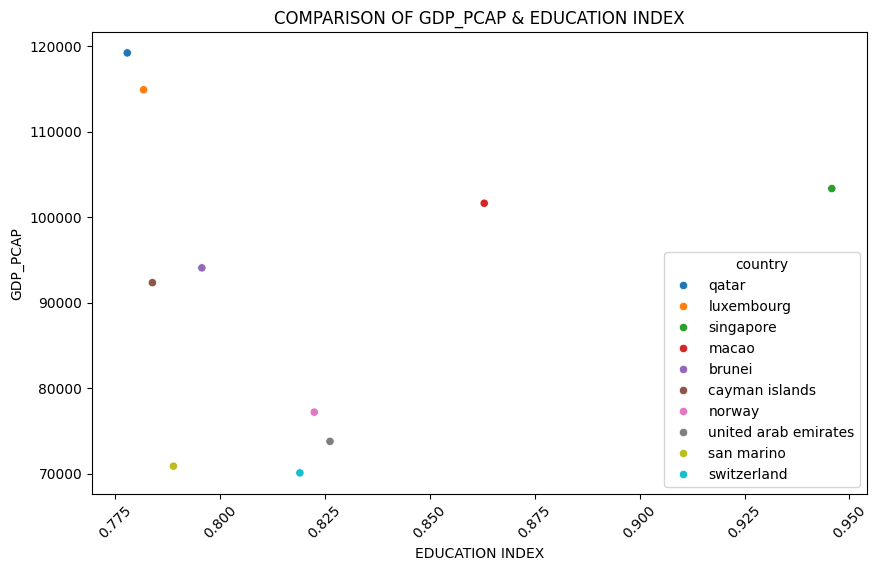

In [ ]:
GDP_school =pd.read_sql("SELECT * FROM GDP_schooling", con = connection)
gdp_education_data = GDP_school.groupby("country")[["GDP_PCAP", "Education_index"]].mean().reset_index()
gdp_education_data1 =gdp_education_data.sort_values(by="GDP_PCAP", ascending=False).head(10)
#gdp_education_data1

plt.figure(figsize=(10,6))
sns.scatterplot(data=gdp_education_data1, x= gdp_education_data1["Education_index"], y=gdp_education_data1["GDP_PCAP"], hue = "country",legend= True)
plt.xlabel("EDUCATION INDEX")
plt.ylabel("GDP_PCAP")
plt.title("COMPARISON OF GDP_PCAP & EDUCATION INDEX")
plt.xticks(rotation=45)
plt.show()

In [ ]:
cursor.execute("DROP TABLE gdp_schooling")
print("Table 'gdp_schooling' dropped successfully. Please run the CREATE TABLE and INSERT cells next.")

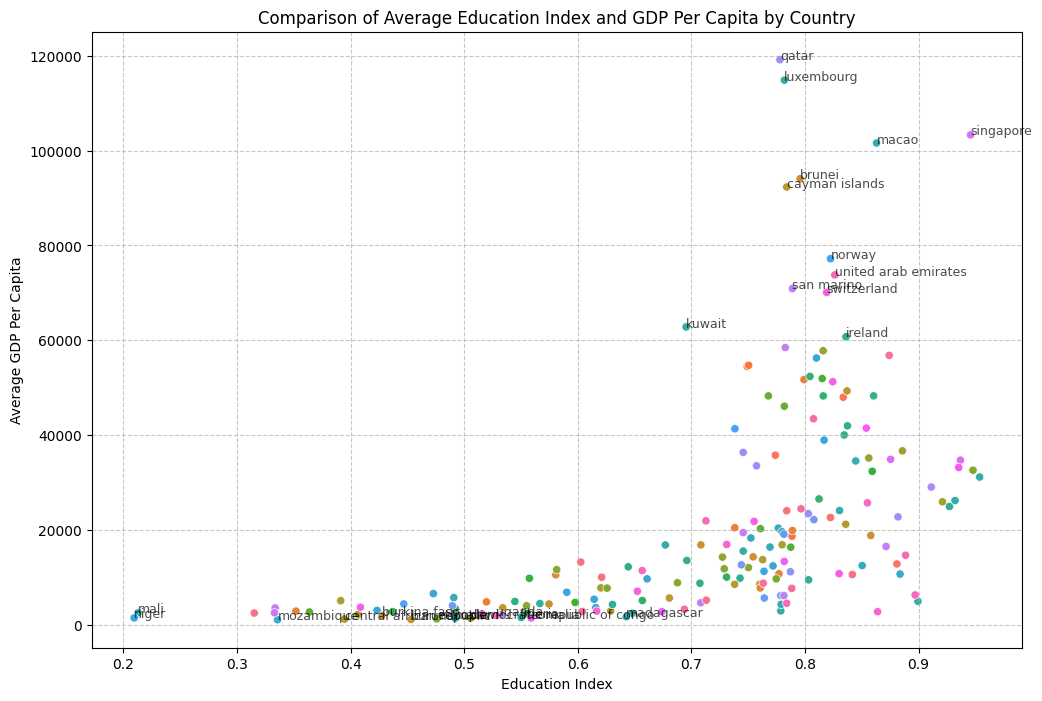

In [ ]:
gdp_education_data = GDP_school.groupby("country")[["GDP_PCAP", "Education_index"]].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=gdp_education_data, x="Education_index", y="GDP_PCAP", hue="country", legend=False)

# Optional: Annotate some of the points to see specific countries
for i, row in gdp_education_data.iterrows():
    if row["GDP_PCAP"] > 60000 or row["Education_index"] < 0.3 or row["GDP_PCAP"] < 2000:
        plt.text(row["Education_index"], row["GDP_PCAP"], row["country"], fontsize=9, alpha=0.7)

plt.xlabel("Education Index")
plt.ylabel("Average GDP Per Capita")
plt.title("Comparison of Average Education Index and GDP Per Capita by Country")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
!pip install plotly.express

In [ ]:
cursor.execute("PRAGMA database_list;")
rows = cursor.fetchall()
for row in rows:
    print(row)

(0, 'main', '/content/drive/MyDrive/A Global Literacy/Untitled Folderliteracy_final.db')


In [ ]:
%%writefile "/content/drive/MyDrive/global literacy projects/Global_literacy.py"
import streamlit as st
import pandas as pd
from datetime import date, timedelta

from streamlit_option_menu import option_menu
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import mplcursors
import plotly.express as px

# Must be the first Streamlit command used
st.set_page_config(layout="wide")

connection = sqlite3.connect("/content/drive/MyDrive/A Global Literacy/Untitled Folderliteracy_final.db")
cursor = connection.cursor()

with st.sidebar:
    selected = option_menu("Navigation", ["Queries","Visualizations","country Profile"],
        icons=['Search','search','radio',], menu_icon="cast", default_index=0)



if selected == "Queries":
     st.title("GLOBAL LITERACY ANALYSIS")
     st.write("Global GDP & Literacy |SQL Powered analysis")
     option = st.selectbox(
    "Select a query",
    ("1.Get top 5 countries with highest adult literacy in 2020",
     "2.Find countries where female youth literacy < 80%",
     "3.Average adult literacy per continent (owid region)",
     "4.Countries with illiteracy % > 20% in 2000",
     "5.Trend of illiteracy % for India (2000–2020)",
     "6.Top 10 countries with largest illiterate population in the last year",
     "7.Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000",
     "8.Rank countries by GDP per schooling for the year 2020",
     "9.Find global average schooling years per year",
     "10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling",
     "11.Show countries where the illiterate population is high despite having more than 10 average years of schooling",
     "12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years",
     "13.Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000"
     ),
     key='main_query_selector'
     )

     pd.options.display.float_format = "{:,.2f}".format
     if option == "1.Get top 5 countries with highest adult literacy in 2020":
         df = pd.read_sql("SELECT country, year, adult_literacy_rate FROM literacy_rate WHERE year = 2020 ORDER BY adult_literacy_rate DESC LIMIT 5",con = connection)
         st.dataframe(df)
         st.divider()
         df = pd.read_sql("SELECT country, year, adult_literacy_rate FROM literacy_rate WHERE year = 2020 ORDER BY adult_literacy_rate DESC LIMIT 5",con = connection)
         fig=plt.figure(figsize=(10,6))
         #plt.matplotlib.pyplot.bar(df["country"], df["adult_literacy_rate"])
         ax= sns.barplot(data=df, x="country", y ="adult_literacy_rate", hue ="country" )
         for p in ax.containers:
             ax.bar_label(p)
         plt.xlabel("country")
         plt.ylabel("literacy rate")
         plt.title("TOP 5 Country with Adult Litreacy Rate")
         st.pyplot(fig)

     if option == "2.Find countries where female youth literacy < 80%":
         df = pd.read_sql(" SELECT country, year, youth_literacy_female FROM literacy_rate WHERE youth_literacy_female < 80",con = connection)
         fig =px.line(df, x="year", y="youth_literacy_female", color="country",title="counries wiht Female Literacy above 80 % Over the years",markers=True,
                      hover_data=["country","year","youth_literacy_female"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         fig=plt.figure(figsize=(15,6))
         sns.lineplot(data=df, x="country", y="youth_literacy_female")
         #ax.plot(df["country"], df["youth_literacy_female"], marker="*")
         #mplcursors.cursor(ax, hover= True)
         plt.xlabel("country")
         plt.ylabel("youth literacy female")
         plt.title("Countries with Female Youth Literacy < 80%")
         plt.xticks(rotation=90)
         st.pyplot(fig)
         st.dataframe(df)


     if option == "3.Average adult literacy per continent (owid region)":
         df = pd.read_sql("SELECT region, AVG(adult_literacy_rate) AS AVG_adult_literacy FROM literacy_rate Group BY region",con = connection)
         fig=plt.figure(figsize=(10,6))
         #plt.matplotlib.pyplot.bar(df["country"], df["adult_literacy_rate"])
         ax= sns.barplot(data=df, x="region", y ="AVG_adult_literacy", hue ="region" )
         for p in ax.containers:
             ax.bar_label(p)
         plt.xlabel("regio")
         plt.ylabel("Avg_adult_literacy rate")
         plt.title("Average Adult Literacy Per Continent Wise")
         st.pyplot(fig)
         st.dataframe(df)

     if option == "4.Countries with illiteracy % > 20% in 2000":
         df = pd.read_sql("SELECT country, illiteracy_rate FROM illiteracy_rate Where year = 2000 AND illiteracy_rate>20",con = connection)
         fig =px.line(df, x="country", y="illiteracy_rate",title="4.Countries with illiteracy % > 20% in 2000",markers=True,
                      hover_data=["country","illiteracy_rate"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)

     if option == "5.Trend of illiteracy % for India (2000–2020)":
         df = pd.read_sql("SELECT country, year, illiteracy_rate FROM illiteracy_rate WHERE country = 'India' AND year BETWEEN 2000 AND 2020",con = connection)
         fig =plt.figure(figsize=(5,3))
         sns.lineplot(df, x="year", y="illiteracy_rate")
         plt.title("Trend of illiteracy % for India (2000–2020)")
         plt.xlabel("year")
         plt.ylabel("illiteracy_rate")
         st.pyplot(fig)
         st.dataframe(df)

     if option == "6.Top 10 countries with largest illiterate population in the last year":
         df = pd.read_sql("SELECT country,year, illiteracy_rate FROM illiteracy_rate WHERE year = (SELECT MAX(year) FROM illiteracy_rate) ORDER BY illiteracy_rate DESC LIMIT 10",con = connection)
         df1=df["year"][0]
         fig=plt.figure(figsize=(10,6))
         #plt.matplotlib.pyplot.bar(df["country"], df["adult_literacy_rate"])
         ax= sns.barplot(data=df, x="country", y ="illiteracy_rate", hue ="country" )
         for p in ax.containers:
             ax.bar_label(p)
         plt.xlabel("country")
         plt.ylabel("illitearcy rate")
         plt.title(f"TOP 10 Countries With Largest Illiteracy Population in Last year {df1}")
         plt.xticks(rotation=70)
         st.pyplot(fig)
         st.dataframe(df)

     if option == "7.Find countries with avg_years_schooling > 7 and gdp_per_capita < 5000":

         df = pd.read_sql("SELECT country, Average_years_of_education, GDP_PCAP FROM gdp_schooling WHERE Average_years_of_education>7 AND GDP_PCAP < 5000",con = connection)
         df1=df.groupby("country")["Average_years_of_education"].mean().reset_index()

         fig =px.line(df1, x="country", y="Average_years_of_education", title="countries with avg_years_schooling > 7 and gdp_per_capita < 5000",markers=True,
                      hover_data=["country","Average_years_of_education"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)

     if option == "8.Rank countries by GDP per schooling for the year 2020":
         df = pd.read_sql("SELECT country,GDP_per_year_of_Education, RANK() OVER (ORDER BY GDP_per_year_of_Education DESC) AS RANK_Country FROM gdp_schooling WHERE year =2020",con = connection)
         df1=df.head(10)
         fig=plt.figure(figsize=(10,6))
         #plt.matplotlib.pyplot.bar(df["country"], df["adult_literacy_rate"])
         ax= sns.barplot(data=df1, x="country", y ="GDP_per_year_of_Education", hue ="country" )
         for p in ax.containers:
             ax.bar_label(p)
         plt.xlabel("country")
         plt.ylabel("illitearcy rate")
         plt.title(f"TOP 10 RANK countries By GDP Per Schooling For The Year of 2020")
         plt.xticks(rotation=70)
         st.pyplot(fig)
         st.dataframe(df)
         st.dataframe(df)

     if option == "9.Find global average schooling years per year":
         df = pd.read_sql("SELECT year, AVG(Average_years_of_education) AS Avg_year_of_education  FROM gdp_schooling GROUP BY year",con = connection)
         fig =px.line(df, x="year", y="Avg_year_of_education",title="Global Average Schooling Years Per Year",markers=True,
                      hover_data=["year","Avg_year_of_education"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)
         st.dataframe(df)

     if option == "10.List top 10 countries in 2020 with highest GDP per capita but lowest average years of schooling":
         df = pd.read_sql("SELECT country,GDP_PCAP,Average_years_of_education FROM gdp_schooling WHERE year = 2020 AND Average_years_of_education <6 ORDER BY GDP_PCAP DESC LIMIT 10",con = connection)
         fig =px.line(df, x="country", y="GDP_PCAP",title="Top 10 countries in 2020 With Highest GDP Per Capita But Lowest Average Years of Schooling",markers=True,
                      hover_data=["country","GDP_PCAP","Average_years_of_education"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)


     if option == "11.Show countries where the illiterate population is high despite having more than 10 average years of schooling":
         df = pd.read_sql("""SELECT
                  il.country AS country,
                  il.illiteracy_rate,
                  gd.Average_years_of_education
                  FROM
                  illiteracy_rate AS il
                  INNER JOIN gdp_schooling AS gd
                  ON
                  LOWER(il.country) = LOWER(gd.country) AND il.year = gd.year
                  WHERE
                  gd.Average_years_of_education >= 10 AND il.illiteracy_rate
                  GROUP BY
                  il.country
                  ORDER BY il.illiteracy_rate DESC""",con = connection)
         fig =px.line(df, x="country", y="illiteracy_rate",title="Countries With High Illiterate Population and More than 10 Of Average Years of Schools ",markers=True,
               hover_data=["country","illiteracy_rate","Average_years_of_education"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)


     if option == "12.Compare literacy rates and GDP per capita growth for a selected country over the last 20 years":
         country=pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
         selected_country = st.selectbox("Select a country", country)
         df = pd.read_sql(f"""
             SELECT
             gd.year,
             gd.GDP_PCAP,
             lr.adult_literacy_rate
             FROM gdp_schooling gd
             INNER JOIN literacy_rate lr ON LOWER(gd.country) = LOWER(lr.country) AND gd.year = lr.year
             WHERE LOWER(gd.country) = '{selected_country}' AND gd.year >= (SELECT MAX(year) - 20 FROM gdp_schooling)
             ORDER BY
             gd.year
             """,con = connection)
         fig =px.line(df, x="year", y="GDP_PCAP",title=f"Comparison Of Literacy Rate & GDP_PCAP for \t{selected_country}",markers=True,
                      hover_data=["year","GDP_PCAP","adult_literacy_rate"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)


     if option == "13.Show the difference between youth literacy male and female rates for countries with GDP per capita above $30,000":
         df = pd.read_sql("""
                      SELECT
                      lr.country,
                      lr.year,
                      ABS(lr.youth_literacy_male - lr.youth_literacy_female) AS youth_literacy_difference,
                      dg.GDP_PCAP
                      FROM
                      literacy_rate lr
                      INNER JOIN
                      gdp_schooling dg ON LOWER(lr.country) = LOWER(dg.country) AND lr.year = dg.year
                      WHERE
                      dg.year = 2020 AND dg.GDP_PCAP > 30000
                      ORDER BY
                      youth_literacy_difference DESC
                      """,con = connection)
         fig =px.line(df, x="country", y="youth_literacy_difference",title=f"Youth Literacy Diffrence Counries Having The GDP_PCAP Above $30000",markers=True,
                      hover_data=["country","GDP_PCAP","youth_literacy_difference"])
         fig.update_traces(mode="markers+lines")
         fig.update_layout(hovermode="x unified")
         st.plotly_chart(fig)
         st.dataframe(df)

if selected == "Visualizations":
     st.title("EDA Visualization")
     st.write("")
     option = st.selectbox(
    "Select a query",
    ("Describes of the Literacy_rate Data Frame",
     "Describes of the Iliteracy_rate Data Frame",
     "Describes of the GDP Schooling Data Frame",
     "Country Wise youth Literacy Average Comparison",
     "CDF and PDF plots",
     "1.COMPARISION OF ALL LITERACY RATE OVER THE YEARS",
     "2.TOP 10 lowest Literacy rate countries",
     "3.TOP 10 highest illiteracy rate countries",
     "4.TOP 10 countries with highest GDP & Education Index to desired the investment",
     "5.Youth literacy percentage distribution",
     "6.Distribution of Average Literacy Rate",
     "7.Distribution of Adult Literacy Rate",
     "8.Distribution of illiteracy Rate",
     "9.BOX Plot for different Regions",
     "10.Adult Literacy Rate Distribution for Top 10 countries",
     "11.GDP Distribution rate",
     "12.Literacy Rate VS GDP",
     "13.India GDP Trend Over the Years",
     "14.Correlation MAP fo the GDP_Schooling datas",
     "15.India Correlation MAP fo the GDP_Schooling datas",
     "16.Correlation MAP fo the literacy_rate datas",
     "17.India Correlation MAP for the literacy_rate datas"
     ),
     key='vis_query_selector'
     )
     if option == "Describes of the Literacy_rate Data Frame":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
         df=df_literacy.describe()
         st.dataframe(df)
     if option == "Describes of the Iliteracy_rate Data Frame":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")
         df=df_literacy.describe()
         st.dataframe(df)
     if option == "Describes of the GDP Schooling Data Frame":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_schooling_cleaned.csv")
         df=df_literacy.describe()
         st.dataframe(df)

     if option == "Country Wise youth Literacy Average Comparison":
         country_1=pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
         selected_country_1 = st.selectbox("Select a country", country_1, key='country_compare_1')
         country_2=pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
         selected_country_2 = st.selectbox("Select a country", country_2, key='country_compare_2')
         st.write(f"You selected countries: {selected_country_1},{selected_country_2}")
         df_literacy_data = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv") # Load literacy data once
         df1 = df_literacy_data[df_literacy_data['country'] == f'{selected_country_1}']
         df2= df_literacy_data[df_literacy_data['country'] == f'{selected_country_2}']

         fig = plt.figure(figsize=(10,6))
         # Plot youth_literacy_average against year for the first country
         plt.scatter(df1['year'], df1['youth_literacy_average'], label=f'{selected_country_1.capitalize()} youth literacy average', color='blue', s=100)
         # Plot youth_literacy_average against year for the second country
         plt.scatter(df2['year'], df2['youth_literacy_average'], label=f'{selected_country_2.capitalize()} youth literacy average', color='red', s=100)

         plt.xlabel("Year")
         plt.ylabel("Youth Literacy Average (%)")
         plt.title(f'Youth Literacy Average Comparison: {selected_country_1.capitalize()} vs {selected_country_2.capitalize()}')
         plt.legend()
         plt.grid(True)
         st.pyplot(fig)

     if option == "CDF and PDF plots":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
         df_literacy=df_literacy[df_literacy["country"]=="india"]
         fig=plt.figure(figsize=(5,3))
         sns.kdeplot(data=df_literacy["adult_literacy_rate"], fill=True, label ='PDF"')
         sns.kdeplot(data=df_literacy["adult_literacy_rate"], cumulative=True, label ='CDF"')
         plt.title("PDF and CDF for literacy rate")
         plt.xlabel("literacy rate")
         plt.ylabel("Frequency")
         st.pyplot(fig)


     if option == "1.COMPARISION OF ALL LITERACY RATE OVER THE YEARS":
         df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
         #country= input("enter the country name")
         #df= df_literacy[df_literacy['country'] == f'{country}']
         df= df_literacy[df_literacy['country'] == 'india']
         country = 'india' # Define country for the plot title

         fig=plt.figure(figsize=(12, 7))
         sns.lineplot(data=df, x='year', y='adult_literacy_rate', label='Adult Literacy Rate')
         sns.lineplot(data=df, x='year', y='youth_literacy_male', label='Youth Literacy (Male)')
         sns.lineplot(data=df, x='year', y='youth_literacy_female', label='Youth Literacy (Female)')

         plt.title(f'Literacy Gender gap Trends in {country} Over Years')
         plt.xlabel('Year')
         plt.ylabel('Literacy Rate (%)')
         plt.legend()
         plt.grid(True, linestyle='--', alpha=0.7)
         st.pyplot(fig)
     if option =="2.TOP 10 lowest Literacy rate countries":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        df=df_literacy.groupby("country")["adult_literacy_rate"].mean().reset_index()
        df_lowest_literacy = df.sort_values(by='adult_literacy_rate', ascending=True).reset_index()
        df_lowest_literacy=df_lowest_literacy.head(10)
        st.dataframe(df_lowest_literacy)

        fig=plt.figure(figsize=(10,6))
        plt.bar(df_lowest_literacy["country"], df_lowest_literacy["adult_literacy_rate"])
        plt.xlabel("country")
        plt.ylabel("literacy rate")
        plt.title("10 lowest literacy rate")
        plt.xticks(rotation=45)
        st.pyplot(fig)
     if option =="3.TOP 10 highest illiteracy rate countries":
        df_illiteracy=pd.read_sql("SELECT * FROM illiteracy_rate",con = connection)
        df_avg_illiteracy = df_illiteracy.groupby("country")["illiteracy_rate"].mean().reset_index()
        df_high_illiteracy = df_avg_illiteracy.sort_values(by='illiteracy_rate', ascending=False).head(10)
        st.dataframe(df_high_illiteracy)

        fig=plt.figure(figsize=(10,6))
        plt.bar(df_high_illiteracy["country"], df_high_illiteracy["illiteracy_rate"])
        plt.xlabel("country")
        plt.ylabel("illiteracy rate")
        plt.title("10 highest illiteracy rate")
        plt.xticks(rotation=45)
        st.pyplot(fig)

     if option =="4.TOP 10 countries with highest GDP & Education Index to desired the investment":
        GDP_school =pd.read_sql("SELECT * FROM gdp_schooling", con = connection)
        gdp_education_data = GDP_school.groupby("country")[["GDP_PCAP", "Education_index"]].mean().reset_index()
        gdp_education_data1 =gdp_education_data.sort_values(by="GDP_PCAP", ascending=False).head(10)
        #st.dataframe(gdp_education_data1)

        fig=plt.figure(figsize=(10,6))
        sns.scatterplot(data=gdp_education_data1, x= gdp_education_data1["Education_index"], y=gdp_education_data1["GDP_PCAP"], hue = "country",legend= True)
        plt.xlabel("EDUCATION INDEX")
        plt.ylabel("GDP_PCAP")
        plt.title("COMPARISON OF GDP_PCAP & EDUCATION INDEX")
        plt.xticks(rotation=45)
        st.pyplot(fig)
     if option =="5.Youth literacy percentage distribution":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(3,3))
        sns.lineplot(data=df_literacy, x="year", y= df_literacy["youth_literacy_PCT"][df_literacy["country"]== "india"])
        plt.title("Distribution of youth literacy percentage year by year")
        plt.ylabel("youth literacy PCT (%)")
        plt.xlabel("year")
        st.pyplot(fig)
     if option == "6.Distribution of Average Literacy Rate":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(3,3))
        sns.histplot(df_literacy["youth_literacy_average"], bins=30, kde=True)
        plt.title("Distribution of Average Literacy Rate")
        plt.xlabel("Average Youth Literacy Rate (%)")
        plt.ylabel("Frequency")
        st.pyplot(fig)
     if option == "7.Distribution of Adult Literacy Rate":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(5,5))
        sns.histplot(df_literacy["adult_literacy_rate"], bins=30, kde=True)
        plt.title("Distribution of Adult Literacy Rate")
        plt.xlabel("Adult Literacy Rate (%)")
        plt.ylabel("Frequency")
        st.pyplot(fig)
     if option == "8.Distribution of illiteracy Rate":
        df_illiteracy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/illiteracy_rate.csv")
        fig=plt.figure(figsize=(3,3))
        sns.histplot(df_illiteracy["illiteracy_rate"], bins=30, kde=True)
        plt.title("Distribution of Illiteracy Rate")
        plt.xlabel("Illiteracy Rate (%)")
        plt.ylabel("Frequency")
        st.pyplot(fig)

     if option == "9.BOX Plot for different Regions":
        df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
        fig=plt.figure(figsize=(3,3))
        sns.boxplot(x='region',y='youth_literacy_average',data=df_literacy)
        plt.title("Box Plot for different Regions")
        plt.xlabel("Region")
        plt.ylabel("Average Literacy Rate")
        plt.xticks(rotation=45)
        st.pyplot(fig)
     if option == "10.Adult Literacy Rate Distribution for Top 10 countries":
       df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
       top10_countries = df_literacy['country'].value_counts().nlargest(10).index
       df_top10 = df_literacy[df_literacy['country'].isin(top10_countries)]
       fig=plt.figure(figsize=(10,6))
       sns.boxplot(data=df_top10,
       x='country',
       y='adult_literacy_rate'
       )
       plt.xticks(rotation=45)
       plt.title("Adult Literacy Rate Distribution for Top 10 Countries")
       plt.xlabel("Country")
       plt.ylabel("Adult Literacy Rate")
       st.pyplot(fig)

     if option == "11.GDP Distribution rate":
       GDP_school =pd.read_sql("SELECT * FROM gdp_schooling", con = connection)
       fig=plt.figure(figsize=(3,3))
       sns.histplot(GDP_school["GDP_PCAP"], bins=30, kde=True)
       plt.title("Distribution of GDP PER CAPITA DISTRIBUTION")
       plt.xlabel("GDP_PCAP")
       plt.ylabel("Frequency")
       st.pyplot(fig)

     if option == "12.Literacy Rate VS GDP":
       GDP_school =pd.read_sql("SELECT * FROM gdp_schooling", con = connection)
       fig=plt.figure(figsize=(3,3))
       sns.scatterplot(data=GDP_school, y="GDP_PCAP", x="literacy_rate")
       plt.title("literacy rate VS GDP_PCAP")
       plt.xlabel("GDP_PCAP")
       plt.ylabel("literacy_rate")
       st.pyplot(fig)

     if option == "13.India GDP Trend Over the Years":
       df_GDP= pd.read_csv("/content/drive/MyDrive/A Global Literacy/GDP_cleaned.csv")
       fig =plt.figure(figsize=(10,5))
       india_gdp_data = df_GDP[df_GDP["country"]=="india"]
       sns.lineplot(data=india_gdp_data, x="year", y ="GDP_PCAP", label='GDP per Capita')
       plt.title('GDP_PCAP Trend Over the year')
       plt.xlabel('Year')
       plt.ylabel('GDP_PCAP')
       plt.legend()
       plt.grid(True, linestyle='--', alpha=0.7)
       plt.xticks(india_gdp_data['year'].unique(), rotation=90)
       plt.tight_layout() # Adjust layout to prevent labels from being cut off
       st.pyplot(fig)

     if option == "14.Correlation MAP fo the GDP_Schooling datas":
       GDP_school =pd.read_sql("SELECT * FROM gdp_schooling", con = connection)
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(GDP_school.select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)

     if option == "15.India Correlation MAP fo the GDP_Schooling datas":
       GDP_school =pd.read_sql("SELECT * FROM gdp_schooling", con = connection)
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(GDP_school[GDP_school["country"]=="india"].select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)

     if option == "16.Correlation MAP fo the literacy_rate datas":
       df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(df_literacy.select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)

     if option == "17.India Correlation MAP for the literacy_rate datas":
       df_literacy = pd.read_csv("/content/drive/MyDrive/A Global Literacy/literacy_rate_cleaned.csv")
       fig=plt.figure(figsize=(10,5))
       sns.heatmap(df_literacy[df_literacy["country"]=="india"].select_dtypes(include=['number']).corr(), annot=True, cmap="viridis", center=0)
       st.pyplot(fig)



if selected == "country Profile":
     st.title("Tends of The GDP,illiteracy & literacy - Analysis Over the Years")
     st.write("Country Wise")

     country =pd.read_sql("SELECT DISTINCT country FROM literacy_rate", con = connection)["country"].tolist()
     selected_country = st.selectbox("Select a country", country, key='country_profile_selector')
     st.write(f"You selected: {selected_country}")
     data = pd.read_sql(f"""SELECT
                        li.country,
                        li.year,
                        li.adult_literacy_rate,
                        li.youth_literacy_average,
                        li.youth_literacy_male,
                        li.youth_literacy_female,
                        li.literacy_gender_gap,
                        li.youth_literacy_ratio,
                        il.illiteracy_rate,
                        li.youth_literacy_PCT,
                        li.youth_literacy_index,
                        gdp.Average_years_of_education,
                        gdp.Population_historical,
                        gdp.GDP_PCAP,
                        gdp.Total_GDP
                 FROM
                       literacy_rate li
                 JOIN
                       illiteracy_rate il ON li.year=il.year AND LOWER(li.country) = LOWER(il.country)
                 JOIN
                       gdp_schooling gdp ON li.year=gdp.year AND LOWER(li.country) = LOWER(gdp.country)
                 WHERE
                       LOWER(li.country) = '{selected_country}'
                       ORDER BY li.year""", con = connection)
     pd.options.display.float_format = "{:,.2f}".format
     st.dataframe(data)

Overwriting /content/drive/MyDrive/global literacy projects/Global_literacy.py


In [ ]:
with open("/content/drive/MyDrive/global literacy projects/Global_literacy.py", "r") as f:
    lines = f.readlines()
    if len(lines) >= 314:
        print(f"Line 314: {lines[313].strip()}")
    else:
        print("File does not have 314 lines.")

In [ ]:
df_literacy


,country,year,adult_literacy_rate,youth_literacy_male,youth_literacy_female,region,literacy_gender_gap,youth_literacy_average,youth_literacy_PCT,youth_literacy_index
0,afghanistan,2011,31.00,62.00,32.00,asia,30.00,47.00,0.00,0.52
1,afghanistan,2015,33.75,57.74,25.48,asia,32.25,41.61,-11.47,0.44
2,afghanistan,2021,37.00,71.00,42.00,asia,29.00,56.50,35.79,0.59
3,afghanistan,2022,66.41,83.40,44.17,asia,39.23,63.79,12.90,0.53
4,albania,2001,99.00,99.00,99.00,europe,0.00,99.00,0.00,1.00
...,...,...,...,...,...,...,...,...,...,...
1695,zambia,2018,71.13,82.45,72.91,africa,9.54,77.68,-12.72,0.88
1696,zimbabwe,1992,84.00,97.00,94.00,africa,3.00,95.50,0.00,0.97
1697,zimbabwe,2009,85.08,93.92,95.65,africa,1.73,94.79,-0.75,1.02
1698,zimbabwe,2014,85.08,93.92,96.31,africa,2.39,95.12,0.35,1.03


In [ ]:
Ireland=pd.read_sql("SELECT * FROM illiteracy_rate Where country='Ireland'", con = connection)
Ireland

,country,year,illiteracy_rate,literacy_rate,literacy_gap
0,Ireland,1475,100.00,0.00,100
1,Ireland,1550,100.00,0.00,100
2,Ireland,1650,97.00,3.00,94
3,Ireland,1750,79.00,21.00,58
4,Ireland,1950,1.50,98.50,97
